# Company Investment Report v2
## 개별 기업 영업현황 · FCFF · 상대가치 종합 보고서

---
### v2 변경 사항 (FCFF_DCF_Valuation_v7 로직 통일)

| 항목 | v1 (구) | v2 (신) |
|------|---------|--------|
| OPM 예측 | 과거 N분기 중앙값 | **SARIMA+ETS+Theta 앙상블** (DCFModel.estimate_opm 동일) |
| OP 산출 | Sales × OPM_median | **Sales × OPM_forecast** (분기별 시계열 예측값) |
| NI 산출 | Sales × NPM_median | **EBIT × (1 - eff_tax) = NOPAT** (이자 제외 세후 영업이익) |
| FCFF 예측 | DB 결과 조회만 | **NOPAT + D&A - CapEx - ΔNWC** (직접 재계산, DB와 동일 로직) |
| D&A/CapEx/NWC | 단순 중앙값 비율 | **OLS slope (R²≥0.30) or median ratio** (동일 estimate_ratio_coef) |

**데이터 흐름**
```
[DB] us_revenue_forecast_data
   └─ Sales actual + forecast (Ensemble → SARIMA → ETS → Theta 우선순위)
          │
          ▼
[FMP API] income-statement → 과거 OPM 시계열
          │  SARIMA+ETS+Theta 앙상블
          ▼
   OPM_forecast (분기별)
          │
          ▼
   EBIT  = Sales × OPM_forecast
   NOPAT = EBIT  × (1 - eff_tax_rate)   ← "NI" 역할
   FCFF  = NOPAT + D&A - CapEx - ΔNWC
```

**사용 DB 테이블**
- `us_revenue_forecast_data` : 매출 실적/예측
- `us_fcff_dcf_valuation`    : FCFF DCF 적정주가 결과
- `us_relative_valuation`    : 상대가치 적정주가 결과


## Cell 1 · 경로 자동 감지

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# ── 후보 프로젝트 루트 (노트북 / 데스크탑) ────────────────────
_CANDIDATE_ROOTS = [
    "C:/Users/Hoyoung_Park/PyCharmMiscProject/stock_forecast",
    "C:/Users/82108/OneDrive/바탕 화면/investment/investment_strategy",
]

def _setup_path() -> str:
    try:
        start = Path(__file__).resolve().parent
    except NameError:
        start = Path.cwd()
    for p in [start] + list(start.parents):
        if (p / "DATA").is_dir():
            root = str(p)
            if root not in sys.path:
                sys.path.insert(0, root)
            print(f"[PATH] root 자동 감지 : {root}")
            return root
    for candidate in _CANDIDATE_ROOTS:
        if os.path.isdir(candidate) and os.path.isdir(os.path.join(candidate, "DATA")):
            if candidate not in sys.path:
                sys.path.insert(0, candidate)
            print(f"[PATH] root 후보 경로 : {candidate}")
            return candidate
    raise EnvironmentError(
        "DATA 폴더를 찾을 수 없습니다.\n"
        "_CANDIDATE_ROOTS 를 현재 환경에 맞게 수정하세요."
    )

_ROOT = _setup_path()
print(f"[확인] 프로젝트 루트 : {_ROOT}")
print(f"[확인] DATA 경로    : {os.path.join(_ROOT, 'DATA')}")

[PATH] root 자동 감지 : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[확인] 프로젝트 루트 : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[확인] DATA 경로    : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA


## Cell 2 · Import & 설정

> **★ 분석 대상 티커를 여기서 지정하세요 ★**

In [2]:
# ── 표준 / 외부 라이브러리 ────────────────────────────────────
import gc, math, time, traceback
import requests
from datetime import datetime
from typing import Optional, Dict, Any, List, Tuple

import numpy as np
import pandas as pd
import pymysql
from scipy import stats
from IPython.display import display
import matplotlib
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["font.family"] = "DejaVu Sans"
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import text
from pathlib import Path

# ── 내부 모듈 ─────────────────────────────────────────────────
from DATA.config import get_db_info, get_engine
from DATA.us_target_ticker_list_screened_20260411 import ticker_list as US_TICKER_LIST
# DCFModel 과 동일한 OPM 예측 함수 재사용
from DATA.universal_ts_forecast_function_v2 import (
    forecast_sarima,
    forecast_ets,
    forecast_theta,
    infer_freq_alias,
    seasonal_periods_from_freq,
)

def log(tag: str, msg: str):
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}][{tag}] {msg}", flush=True)

# ════════════════════════════════════════════════════════════════
#  ★ 파라미터 — 여기만 수정하세요 ★
# ════════════════════════════════════════════════════════════════
TICKER = "NFLX"        # 분석 대상 티커

# FMP API
FMP_API_KEY = "hT0gAk87j9xZx4PlBApvBqfVL5IahvgV"
FMP_BASE    = "https://financialmodelingprep.com/api/v3"
FMP_LIMIT   = 40
FMP_SLEEP   = 0.35

# DB 테이블
TABLE_SALES  = "us_revenue_forecast_data"
TABLE_FCFF   = "us_fcff_dcf_valuation"
TABLE_REL    = "us_relative_valuation"
DEFAULT_PORT = 3307

# 표시 분기 수
HIST_QTRS    = 12     # 과거 12분기 (3년)
FWD_QTRS     = 8      # 향후 8분기 (2년)

# DCFModel 과 동일한 상수
MIN_HISTORY      = 20          # OPM 시계열 예측 최소 분기 수
WINSORIZE_LIMITS = (0.05, 0.95)
OLS_MIN_R2       = 0.30
OLS_MIN_SAMPLES  = 20
DEFAULT_TAX_RATE = 0.21

print(f"[OK] 설정 완료  →  분석 대상: {TICKER}")
print(f"[OK] 전체 스크리닝 티커 수: {len(US_TICKER_LIST):,}개")

[OK] 설정 완료  →  분석 대상: NFLX
[OK] 전체 스크리닝 티커 수: 1,026개


## Cell 3 · DB 연결

In [3]:
db_info = get_db_info()
engine  = get_engine(db_info)

def get_conn():
    return pymysql.connect(
        host       = db_info["host"],
        port       = int(db_info.get("port", DEFAULT_PORT)),
        user       = db_info["user"],
        password   = db_info["password"],
        db         = db_info.get("database", "investar"),
        charset    = "utf8mb4",
        autocommit = False,
        cursorclass= pymysql.cursors.DictCursor,
    )

try:
    with engine.connect() as conn:
        conn.execute(text("SELECT 1"))
    log("DB", f"연결 성공  host={db_info.get('host')}  port={db_info.get('port')}  "
              f"db={db_info.get('database')}")
except Exception as e:
    log("DB", f"연결 실패: {e}")

[22:19:04][DB] 연결 성공  host=192.168.0.230  port=3307  db=investar


## Cell 4 · 공통 유틸 & FMP 로드 함수

`DCFModel` 의 `_fmp_get` / `_parse_date_col` / `_winsorize` / `_ols_ratio` 와 동일한 구현

In [4]:
# ═══════════════════════════════════════════════════════════════
#  유틸 — DCFModel 내부 메서드와 100% 동일 로직
# ═══════════════════════════════════════════════════════════════

def _winsorize(s: pd.Series,
               limits: Tuple[float, float] = WINSORIZE_LIMITS) -> pd.Series:
    """DCFModel._winsorize 동일"""
    lo, hi = s.quantile(limits[0]), s.quantile(limits[1])
    return s.clip(lo, hi)


def _ols_ratio(x: pd.Series, y: pd.Series) -> Tuple[float, float]:
    """DCFModel._ols_ratio 동일 — y = slope*x 단순회귀, R² 반환"""
    mask = x.notna() & y.notna() & (x != 0)
    if mask.sum() < OLS_MIN_SAMPLES:
        return np.nan, -1.0
    slope, _, r, _, _ = stats.linregress(x[mask], y[mask])
    return slope, r ** 2


def fmp_get(endpoint: str, ticker: str,
            period: str = "quarter", limit: int = FMP_LIMIT) -> pd.DataFrame:
    """DCFModel._fmp_get 동일"""
    url = f"{FMP_BASE}/{endpoint}/{ticker}"
    for attempt in range(3):
        try:
            r = requests.get(
                url,
                params={"period": period, "limit": limit, "apikey": FMP_API_KEY},
                timeout=20
            )
            if r.status_code == 429:
                time.sleep(1.5 + attempt)
                continue
            r.raise_for_status()
            data = r.json()
            if isinstance(data, dict) and "Error Message" in data:
                return pd.DataFrame()
            return pd.DataFrame(data) if isinstance(data, list) else pd.DataFrame()
        except Exception as e:
            if attempt == 2:
                log(ticker, f"FMP {endpoint} fail: {e}")
                return pd.DataFrame()
            time.sleep(FMP_SLEEP + attempt * 0.5)
    return pd.DataFrame()


def parse_qend(df: pd.DataFrame) -> pd.DataFrame:
    """DCFModel._parse_date_col 동일 — acceptedDate 기반 look-ahead bias 보정"""
    df = df.copy()
    df["report_date"] = pd.to_datetime(
        df.get("acceptedDate", df.get("fillingDate", pd.NaT)), errors="coerce"
    )
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    def _qend(row):
        if pd.notna(row.get("report_date")):
            return (row["report_date"] - pd.Timedelta(days=45)).to_period("Q").to_timestamp("Q")
        return row["date"].to_period("Q").to_timestamp("Q")

    df["date"] = df.apply(_qend, axis=1)
    return (df.sort_values("date")
              .drop_duplicates("date", keep="last")
              .reset_index(drop=True))


# ── FMP 재무제표 로드 ─────────────────────────────────────────
def load_income_statement(ticker: str) -> pd.DataFrame:
    df = fmp_get("income-statement", ticker)
    if df.empty:
        return df
    df = parse_qend(df)
    for c in ["revenue", "operatingIncome", "netIncome",
               "incomeTaxExpense", "pretaxIncome",
               "weightedAverageShsOutDil", "weightedAverageShsOut",
               "interestExpense"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    # 실효세율 — DCFModel.estimate_tax_rate 동일 (pretaxIncome > 0 만)
    if "pretaxIncome" in df.columns and "incomeTaxExpense" in df.columns:
        df["eff_tax_rate"] = np.where(
            df["pretaxIncome"] > 0,
            (df["incomeTaxExpense"] / df["pretaxIncome"]).clip(0, 0.40),
            np.nan
        )
    # 과거 OPM (시계열 예측 입력용)
    if "operatingIncome" in df.columns and "revenue" in df.columns:
        df["opm"] = df["operatingIncome"] / df["revenue"].replace(0, np.nan)
    # 과거 NPM (실적 테이블 표시용)
    if "netIncome" in df.columns and "revenue" in df.columns:
        df["npm"] = df["netIncome"] / df["revenue"].replace(0, np.nan)
    return df


def load_balance_sheet(ticker: str) -> pd.DataFrame:
    df = fmp_get("balance-sheet-statement", ticker)
    if df.empty:
        return df
    df = parse_qend(df)
    for c in ["totalAssets", "totalStockholdersEquity", "totalDebt",
               "cashAndCashEquivalents", "totalCurrentAssets",
               "totalCurrentLiabilities", "shortTermDebt",
               "currentAssets", "currentLiabilities"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    if "totalAssets" in df.columns and "totalStockholdersEquity" in df.columns:
        df["financial_leverage"] = (
            df["totalAssets"] / df["totalStockholdersEquity"].replace(0, np.nan)
        )
    return df


def load_cashflow(ticker: str) -> pd.DataFrame:
    df = fmp_get("cash-flow-statement", ticker)
    if df.empty:
        return df
    df = parse_qend(df)
    for c in ["depreciationAndAmortization", "capitalExpenditure",
               "operatingCashFlow", "changeInWorkingCapital",
               "freeCashFlow", "netIncome", "stockBasedCompensation",
               "amortizationOfIntangibles"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


print("[OK] 공통 유틸 & FMP 로드 함수 정의 완료")

[OK] 공통 유틸 & FMP 로드 함수 정의 완료


## Cell 5 · Sales 로드 & OPM/CapEx/D&A/NWC 추정 함수

`DCFModel.load_sales` / `estimate_opm` / `estimate_ratio_coef` / `estimate_nwc_coef` 와 동일 로직

In [5]:
# ═══════════════════════════════════════════════════════════════
#  Sales 로드 — DCFModel.load_sales 동일
#  우선순위: Ensemble → SARIMA → ETS → Theta
# ═══════════════════════════════════════════════════════════════

def load_sales(ticker: str,
               horizon: int = FWD_QTRS) -> Tuple[pd.Series, pd.Series, str]:
    """
    Returns
    -------
    sales_actual   : pd.Series  index=date  (전체 과거)
    sales_forecast : pd.Series  index=date  (horizon 분기)
    used_model     : str        선택된 forecast 모델명
    """
    conn = get_conn()
    try:
        with conn.cursor() as cur:
            cur.execute(
                f"SELECT date, value FROM `{TABLE_SALES}` "
                f"WHERE ticker=%s AND item='sale' AND data_type='actual' ORDER BY date",
                (ticker,)
            )
            actual_rows = cur.fetchall()

            cur.execute(
                f"SELECT MAX(forecast_date) AS max_fd FROM `{TABLE_SALES}` "
                f"WHERE ticker=%s AND item='sale' AND data_type='forecast'",
                (ticker,)
            )
            row = cur.fetchone()
            max_fd = row["max_fd"] if row else None

            fc_rows = []
            if max_fd:
                cur.execute(
                    f"SELECT date, model, value FROM `{TABLE_SALES}` "
                    f"WHERE ticker=%s AND item='sale' "
                    f"  AND data_type='forecast' AND forecast_date=%s "
                    f"ORDER BY model, date",
                    (ticker, max_fd)
                )
                fc_rows = cur.fetchall()
    finally:
        conn.close()

    if not actual_rows:
        raise ValueError(f"[{ticker}] Sales actual 없음")

    act_df = pd.DataFrame(actual_rows)
    act_df["date"]  = pd.to_datetime(act_df["date"])
    act_df["value"] = pd.to_numeric(act_df["value"], errors="coerce")
    sales_actual = (act_df.sort_values("date")
                          .drop_duplicates("date", keep="last")
                          .set_index("date")["value"])

    if not fc_rows:
        raise ValueError(f"[{ticker}] Sales forecast 없음 (forecast_date={max_fd})")

    fc_df = pd.DataFrame(fc_rows)
    fc_df["date"]  = pd.to_datetime(fc_df["date"])
    fc_df["value"] = pd.to_numeric(fc_df["value"], errors="coerce")

    # 모델 우선순위 — DCFModel.load_sales 와 동일
    priority  = ["Ensemble", "SARIMA", "ETS", "Theta"]
    available = fc_df["model"].unique().tolist()
    ordered   = [m for m in priority if m in available] + \
                [m for m in available if m not in priority]

    sales_forecast = pd.Series(dtype=float)
    used_model     = None
    for model_name in ordered:
        fc = (fc_df[fc_df["model"] == model_name]
              .sort_values("date")
              .drop_duplicates("date", keep="last")
              .set_index("date")["value"]
              .dropna())
        if len(fc) >= horizon:
            sales_forecast = fc.iloc[:horizon]
            used_model     = model_name
            break
        elif len(fc) > 0 and sales_forecast.empty:
            sales_forecast = fc
            used_model     = model_name

    # 부족 시 forward-fill
    if len(sales_forecast) < horizon:
        extra_idx = pd.date_range(
            start   = sales_forecast.index[-1] + pd.offsets.QuarterEnd(1),
            periods = horizon - len(sales_forecast),
            freq    = "QE"
        )
        fill_val       = float(sales_forecast.iloc[-1])
        sales_forecast = pd.concat([
            sales_forecast,
            pd.Series([fill_val] * len(extra_idx), index=extra_idx)
        ])

    return sales_actual, sales_forecast.iloc[:horizon], used_model


# ═══════════════════════════════════════════════════════════════
#  실효세율 추정 — DCFModel.estimate_tax_rate 동일
# ═══════════════════════════════════════════════════════════════

def estimate_tax_rate(inc_df: pd.DataFrame) -> float:
    """pretaxIncome > 0 분기만 사용, clip(0, 0.40), 중앙값"""
    if "pretaxIncome" not in inc_df.columns or "incomeTaxExpense" not in inc_df.columns:
        return DEFAULT_TAX_RATE
    df = inc_df[["pretaxIncome", "incomeTaxExpense"]].copy()
    df = df[df["pretaxIncome"] > 0].dropna()
    if df.empty:
        return DEFAULT_TAX_RATE
    rates = (df["incomeTaxExpense"] / df["pretaxIncome"]).clip(0, 0.40)
    return float(rates.median())


# ═══════════════════════════════════════════════════════════════
#  OPM 예측 — DCFModel.estimate_opm 동일
#  SARIMA + ETS + Theta 앙상블 → clip(-0.50, 0.80)
# ═══════════════════════════════════════════════════════════════

def estimate_opm_forecast(inc_df: pd.DataFrame,
                           sales_fc: pd.Series,
                           horizon: int = FWD_QTRS,
                           min_history: int = MIN_HISTORY) -> pd.Series:
    """
    분기별 OPM 예측 시리즈 반환 (index = sales_fc.index).
    DCFModel.estimate_opm 과 동일 로직.
    """
    fallback_const = 0.10

    if "operatingIncome" not in inc_df.columns or "revenue" not in inc_df.columns:
        log("OPM", "IS 컬럼 없음 → 10% fallback")
        return pd.Series([fallback_const] * len(sales_fc), index=sales_fc.index)

    df = inc_df[["date", "operatingIncome", "revenue"]].copy()
    df["operatingIncome"] = pd.to_numeric(df["operatingIncome"], errors="coerce")
    df["revenue"]         = pd.to_numeric(df["revenue"],         errors="coerce")
    df = df[df["revenue"] > 0].dropna().set_index("date").sort_index()
    df["opm"] = df["operatingIncome"] / df["revenue"]
    df["opm"] = _winsorize(df["opm"])
    opm_series = df["opm"]

    # 데이터 부족 → median fallback
    if len(opm_series) < min_history:
        fallback = float(opm_series.median()) if not opm_series.empty else fallback_const
        fallback = float(np.clip(fallback, -0.50, 0.80))
        log("OPM", f"데이터 부족({len(opm_series)}Q) → median fallback={fallback:.4f}")
        return pd.Series([fallback] * len(sales_fc), index=sales_fc.index)

    # SARIMA + ETS + Theta 앙상블 — DCFModel.estimate_opm 동일
    freq_alias = infer_freq_alias(opm_series.index)
    m          = seasonal_periods_from_freq(freq_alias)

    forecasts = {}
    for name, fn in [
        ("SARIMA", lambda y: forecast_sarima(y, horizon, seasonal_period=m)),
        ("ETS",    lambda y: forecast_ets(y,    horizon, m=m)),
        ("Theta",  lambda y: forecast_theta(y,  horizon, m=m)),
    ]:
        try:
            res = fn(opm_series)
            if "forecast" in res and "error" not in res:
                forecasts[name] = np.asarray(res["forecast"])
        except Exception:
            pass

    if forecasts:
        ens = np.mean(list(forecasts.values()), axis=0)
        ens = np.clip(ens, -0.50, 0.80)
        log("OPM", f"앙상블 완료 ({list(forecasts.keys())})  "
                   f"범위: {ens.min():.3f} ~ {ens.max():.3f}")
        return pd.Series(ens, index=sales_fc.index)

    # 전체 실패 → 최근 8분기 median fallback
    fallback = float(opm_series.tail(8).median() if len(opm_series) >= 8
                     else opm_series.median())
    fallback = float(np.clip(fallback, -0.50, 0.80))
    log("OPM", f"예측 실패 → median fallback={fallback:.4f}")
    return pd.Series([fallback] * len(sales_fc), index=sales_fc.index)


# ═══════════════════════════════════════════════════════════════
#  D&A / CapEx / NWC 비율 계수 — DCFModel.estimate_ratio_coef 동일
#  OLS slope 우선 → R²<0.30 or 표본부족 → median ratio fallback
# ═══════════════════════════════════════════════════════════════

def estimate_ratio_coef(
    inc_df: pd.DataFrame,
    bs_df:  pd.DataFrame,
    cf_df:  pd.DataFrame,
    cf_col: str,
    take_abs: bool = False,
) -> Tuple[float, str]:
    """DCFModel.estimate_ratio_coef 동일 — (coef, method_used) 반환"""
    inc = inc_df[["date", "revenue"]].copy()
    inc["revenue"] = pd.to_numeric(inc["revenue"], errors="coerce")

    if cf_col in cf_df.columns:
        src = cf_df[["date", cf_col]].copy()
    elif cf_col in inc_df.columns:
        src = inc_df[["date", cf_col]].copy()
    elif cf_col in bs_df.columns:
        src = bs_df[["date", cf_col]].copy()
    else:
        return 0.0, "missing"

    src[cf_col] = pd.to_numeric(src[cf_col], errors="coerce")
    if take_abs:
        src[cf_col] = src[cf_col].abs()
    # revenue 도 반드시 numeric 확인 (FMP 일부 컬럼이 str 로 올 수 있음)
    inc["revenue"] = pd.to_numeric(inc["revenue"], errors="coerce")

    merged = inc.merge(src, on="date", how="inner").dropna()
    merged = merged[merged["revenue"] > 0]
    if merged.empty:
        return 0.0, "empty"

    x, y = merged["revenue"], merged[cf_col]
    slope, r2 = _ols_ratio(x, y)

    use_ols = (
        not np.isnan(slope)
        and r2 >= OLS_MIN_R2
        and slope >= 0
        and len(merged) >= OLS_MIN_SAMPLES
    )

    if use_ols:
        return float(slope), "ols"

    ratios = (y / x).replace([np.inf, -np.inf], np.nan).dropna()
    if ratios.empty:
        return 0.0, "ratio_empty"
    med = float(_winsorize(ratios).median())
    return max(med, 0.0), "median_ratio"


def estimate_nwc_coef(
    inc_df: pd.DataFrame,
    bs_df:  pd.DataFrame,
) -> Tuple[float, str]:
    """DCFModel.estimate_nwc_coef 동일
    NWC = (currentAssets - cash) - (totalCurrentLiabilities - shortTermDebt)
    """
    bs = bs_df.copy()
    needed = ["currentAssets", "cashAndCashEquivalents",
               "totalCurrentLiabilities", "shortTermDebt"]
    for c in needed:
        if c not in bs.columns:
            bs[c] = 0.0
        bs[c] = pd.to_numeric(bs[c], errors="coerce").fillna(0)

    bs["nwc"] = (
        (bs["currentAssets"] - bs["cashAndCashEquivalents"])
        - (bs["totalCurrentLiabilities"] - bs["shortTermDebt"])
    )

    inc = inc_df[["date", "revenue"]].copy()
    inc["revenue"] = pd.to_numeric(inc["revenue"], errors="coerce")
    merged = inc.merge(bs[["date", "nwc"]], on="date", how="inner").dropna()
    merged = merged[merged["revenue"] > 0]
    if merged.empty:
        return 0.0, "empty"

    slope, r2 = _ols_ratio(merged["revenue"], merged["nwc"])
    use_ols = (not np.isnan(slope) and r2 >= OLS_MIN_R2
               and len(merged) >= OLS_MIN_SAMPLES)
    if use_ols:
        return float(slope), "ols"

    ratios = (merged["nwc"] / merged["revenue"]).replace([np.inf, -np.inf], np.nan).dropna()
    if ratios.empty:
        return 0.0, "ratio_empty"
    return float(_winsorize(ratios).median()), "median_ratio"


print("[OK] Sales 로드 & 추정 함수 정의 완료")

[OK] Sales 로드 & 추정 함수 정의 완료


## Cell 6 · Pro-Forma 계산 함수

`DCFModel.compute_fcff` 와 동일한 계산 흐름

```
EBIT  = Sales_forecast × OPM_forecast
NOPAT = EBIT × (1 - eff_tax)          ← NI 역할
D&A   = alpha × Sales
CapEx = beta  × Sales
NWC   = gamma × Sales
FCFF  = NOPAT + D&A - CapEx - ΔNWC
```

In [6]:
def build_forward_proforma(
    sales_fc:   pd.Series,
    opm_fc:     pd.Series,
    tax:        float,
    alpha:      float,   # D&A / Sales  (미래 추정 계수)
    beta:       float,   # CapEx / Sales (미래 추정 계수)
    gamma:      float,   # NWC / Sales  (미래 추정 계수)
) -> pd.DataFrame:
    """
    미래 Pro-Forma — 계수 × 예측매출 (기존 동일)
    FCFF = NOPAT + D&A - CapEx - ΔNWC
    """
    rows     = []
    prev_nwc = None
    for i, (dt, sales) in enumerate(sales_fc.items(), 1):
        opm       = float(opm_fc.iloc[i - 1])
        ebit      = sales * opm
        nopat     = ebit * (1 - tax)
        da        = alpha * sales
        capex     = beta  * sales
        nwc       = gamma * sales
        delta_nwc = (nwc - prev_nwc) if prev_nwc is not None else 0.0
        prev_nwc  = nwc
        fcff      = nopat + da - capex - delta_nwc

        rows.append({
            "col_label": f"{i}Q_F",
            "date":      dt,
            "quarter":   f"{dt.year}Q{dt.quarter}",
            "Sales":     sales,
            "OPM":       opm,
            "EBIT":      ebit,
            "NOPAT":     nopat,
            "DA":        da,
            "CapEx":     capex,
            "NWC":       nwc,
            "ΔNWC":      delta_nwc,
            "FCFF":      fcff,
            "source":    "forecast",
        })
    return pd.DataFrame(rows)


def build_hist_fcff(
    sales_actual: pd.Series,
    inc_df:  pd.DataFrame,
    cf_df:   pd.DataFrame,   # ★ 추가 — CF Statement 실제값
    bs_df:   pd.DataFrame,   # ★ 추가 — Balance Sheet 실제값
    tax:     float,
    alpha:   float,          # fallback 전용 (실제값 없을 때만 사용)
    beta:    float,          # fallback 전용
    gamma:   float,          # fallback 전용
    n_qtrs:  int = HIST_QTRS,
) -> pd.DataFrame:
    """
    과거 FCFF — 실제 재무제표 값 사용 (★ 핵심 변경)
    ─────────────────────────────────────────────────
    D&A   : CF Statement depreciationAndAmortization  (실제값)
    CapEx : CF Statement |capitalExpenditure|          (실제값)
    NWC   : BS (currentAssets-cash)-(currentLiab-shortDebt) (실제값)
    OPM   : IS operatingIncome / revenue               (실제값)

    실제값이 없는 분기만 계수×Sales 로 fallback.
    미래 구간(build_forward_proforma)은 기존 계수 방식 유지.
    """
    if inc_df.empty:
        return pd.DataFrame()

    # ── 날짜 인덱스 설정 ────────────────────────────────────────
    # parse_qend 가 date_mapped 를 별도 컬럼으로 만들므로
    # date_mapped 를 우선 사용 (없으면 date 원본 사용)
    def _idx_col(df):
        return "date_mapped" if "date_mapped" in df.columns else "date"

    inc = inc_df.set_index(_idx_col(inc_df))

    cf = pd.DataFrame()
    if not cf_df.empty:
        cf = cf_df.set_index(_idx_col(cf_df))
        for col in ["depreciationAndAmortization", "capitalExpenditure"]:
            if col in cf.columns:
                cf[col] = pd.to_numeric(cf[col], errors="coerce")

    # ── BS → NWC 시계열 미리 계산 ──────────────────────────────
    bs_nwc = pd.Series(dtype=float)
    if not bs_df.empty:
        bs = bs_df.copy()
        bs_dc = _idx_col(bs)
        for col in ["currentAssets", "cashAndCashEquivalents",
                    "totalCurrentLiabilities", "shortTermDebt"]:
            if col not in bs.columns:
                bs[col] = 0.0
            bs[col] = pd.to_numeric(bs[col], errors="coerce").fillna(0)
        bs["_nwc"] = (
            (bs["currentAssets"] - bs["cashAndCashEquivalents"])
            - (bs["totalCurrentLiabilities"] - bs["shortTermDebt"])
        )
        bs_nwc = bs.set_index(bs_dc)["_nwc"]

    # ── 분기별 루프 ─────────────────────────────────────────────
    rows     = []
    prev_nwc = None

    for dt, sales in sales_actual.items():

        # NWC 는 sales=0 이어도 BS 값이 있으면 계산
        nwc_raw = bs_nwc.get(dt, np.nan) if not bs_nwc.empty else np.nan
        nwc     = float(nwc_raw) if pd.notna(nwc_raw) else (gamma * sales if pd.notna(sales) else np.nan)

        if pd.isna(sales) or sales <= 0:
            prev_nwc = nwc
            continue

        # OPM — IS 실제값
        op_val  = inc["operatingIncome"].get(dt, np.nan) if "operatingIncome" in inc.columns else np.nan
        rev_val = inc["revenue"].get(dt, np.nan)         if "revenue"         in inc.columns else np.nan
        opm     = (float(op_val) / float(rev_val)
                   if (pd.notna(op_val) and pd.notna(rev_val) and float(rev_val) > 0)
                   else np.nan)
        if pd.isna(opm):
            prev_nwc = nwc
            continue

        ebit  = sales * opm
        nopat = ebit * (1 - tax)

        # D&A — CF 실제값, 없으면 alpha×Sales
        da_raw = cf["depreciationAndAmortization"].get(dt, np.nan) if (not cf.empty and "depreciationAndAmortization" in cf.columns) else np.nan
        if pd.notna(da_raw) and float(da_raw) > 0:
            da       = float(da_raw)
            da_src   = "actual"
        else:
            da       = alpha * sales
            da_src   = "fallback"

        # CapEx — CF 실제값 abs(), 없으면 beta×Sales
        cx_raw = cf["capitalExpenditure"].get(dt, np.nan) if (not cf.empty and "capitalExpenditure" in cf.columns) else np.nan
        if pd.notna(cx_raw):
            capex    = abs(float(cx_raw))
            cx_src   = "actual"
        else:
            capex    = beta * sales
            cx_src   = "fallback"

        # NWC source 표시
        nwc_src = "actual" if pd.notna(nwc_raw) else "fallback"

        delta_nwc = (nwc - prev_nwc) if prev_nwc is not None else 0.0
        prev_nwc  = nwc

        fcff = nopat + da - capex - delta_nwc

        rows.append({
            "date":    dt,
            "quarter": f"{dt.year}Q{dt.quarter}",
            "Sales":   sales,
            "OPM":     opm,
            "EBIT":    ebit,
            "NOPAT":   nopat,
            "DA":      da,
            "CapEx":   capex,
            "NWC":     nwc,
            "ΔNWC":    delta_nwc,
            "FCFF":    fcff,
            "source":  "actual",
            "_da_src":  da_src,    # 디버그용
            "_cx_src":  cx_src,
            "_nwc_src": nwc_src,
        })

    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    return df.tail(n_qtrs).reset_index(drop=True)


print("[OK] build_forward_proforma / build_hist_fcff (실제값 버전) 정의 완료")


[OK] build_forward_proforma / build_hist_fcff (실제값 버전) 정의 완료


## Cell 7 · DB 결과 로드 함수 (FCFF DCF 적정주가 / 상대가치)

In [7]:
def load_fcff_result(ticker: str) -> Optional[Dict]:
    """us_fcff_dcf_valuation — 최신 run_date 결과"""
    conn = get_conn()
    try:
        with conn.cursor() as cur:
            cur.execute(
                f"SELECT MAX(date) AS max_date FROM `{TABLE_FCFF}` WHERE ticker=%s",
                (ticker,)
            )
            row = cur.fetchone()
            max_date = row["max_date"] if row else None
            if not max_date:
                return None
            cur.execute(
                f"SELECT * FROM `{TABLE_FCFF}` WHERE ticker=%s AND date=%s ORDER BY quarter",
                (ticker, max_date)
            )
            rows = cur.fetchall()
    finally:
        conn.close()
    if not rows:
        return None
    df   = pd.DataFrame(rows)
    last = df.iloc[-1]
    return {
        "df":           df,
        "target_price": float(last.get("target_price") or np.nan),
        "current_price": float(last.get("current_price") or np.nan),
        "upside_pct":   float(last.get("upside_pct")    or np.nan),
        "wacc":         float(last.get("discount_rate") or np.nan),
        "g_terminal":   float(last.get("g_terminal")    or np.nan),
        "run_date":     str(max_date),
    }


def load_rel_result(ticker: str) -> Optional[Dict]:
    """us_relative_valuation — 최신 run_date 결과"""
    conn = get_conn()
    try:
        with conn.cursor() as cur:
            cur.execute(
                f"SELECT MAX(date) AS max_date FROM `{TABLE_REL}` WHERE ticker=%s",
                (ticker,)
            )
            row = cur.fetchone()
            max_date = row["max_date"] if row else None
            if not max_date:
                return None
            cur.execute(
                f"SELECT * FROM `{TABLE_REL}` WHERE ticker=%s AND date=%s",
                (ticker, max_date)
            )
            row = cur.fetchone()
    finally:
        conn.close()
    return dict(row) if row else None


def get_current_price(ticker: str) -> float:
    try:
        r = requests.get(f"{FMP_BASE}/quote-short/{ticker}",
                         params={"apikey": FMP_API_KEY}, timeout=10)
        data = r.json()
        if data and isinstance(data, list):
            return float(data[0].get("price", np.nan))
    except Exception:
        pass
    return np.nan


print("[OK] DB 결과 로드 함수 정의 완료")

[OK] DB 결과 로드 함수 정의 완료


## Cell 8 · 전체 데이터 로드 & 계산 실행

모든 계산을 이 셀 한 곳에서 실행합니다.

In [8]:
ticker = TICKER.upper()
print(f"{'='*70}")
print(f"  분석 대상: {ticker}")
print(f"  실행 시각: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"{'='*70}")

# ── 1. Sales 로드 ─────────────────────────────────────────────
try:
    sales_actual, sales_fc, sales_model = load_sales(ticker, FWD_QTRS)
    log(ticker, f"Sales actual={len(sales_actual)}Q  "
                f"forecast={len(sales_fc)}Q  model={sales_model}")
except Exception as e:
    log(ticker, f"Sales 로드 실패: {e}")
    sales_actual = pd.Series(dtype=float)
    sales_fc     = pd.Series(dtype=float)
    sales_model  = "N/A"

# ── 2. FMP 재무제표 로드 ──────────────────────────────────────
log(ticker, "FMP 재무제표 로드 중...")
time.sleep(FMP_SLEEP)
inc_df = load_income_statement(ticker)
time.sleep(FMP_SLEEP)
bs_df  = load_balance_sheet(ticker)
time.sleep(FMP_SLEEP)
cf_df  = load_cashflow(ticker)
log(ticker, f"IS={len(inc_df)}Q  BS={len(bs_df)}Q  CF={len(cf_df)}Q")

# ── 3. 파라미터 추정 (DCFModel 동일 로직) ────────────────────
tax   = estimate_tax_rate(inc_df)
alpha, alpha_m = estimate_ratio_coef(inc_df, bs_df, cf_df,
                                     "depreciationAndAmortization")
beta,  beta_m  = estimate_ratio_coef(inc_df, bs_df, cf_df,
                                     "capitalExpenditure", take_abs=True)
gamma, gamma_m = estimate_nwc_coef(inc_df, bs_df)

log(ticker, f"세율={tax*100:.1f}%  "
            f"D&A/S={alpha:.4f}({alpha_m})  "
            f"CapEx/S={beta:.4f}({beta_m})  "
            f"NWC/S={gamma:.4f}({gamma_m})")

# ── 4. OPM 시계열 예측 (SARIMA+ETS+Theta 앙상블) ─────────────
if not sales_fc.empty:
    opm_fc = estimate_opm_forecast(inc_df, sales_fc, FWD_QTRS)
    log(ticker, f"OPM forecast: {[round(v*100,1) for v in opm_fc.values]}%")
else:
    opm_fc = pd.Series(dtype=float)

# ── 5. 향후 Pro-Forma 계산 ────────────────────────────────────
pf = pd.DataFrame()
if not sales_fc.empty and not opm_fc.empty:
    pf = build_forward_proforma(sales_fc, opm_fc, tax, alpha, beta, gamma)
    log(ticker, f"Forward Pro-Forma: {len(pf)}Q")

# ── 6. 과거 FCFF 계산 ─────────────────────────────────────────
hist_fcff = pd.DataFrame()
if not sales_actual.empty and not inc_df.empty:
    hist_fcff = build_hist_fcff(sales_actual, inc_df, cf_df, bs_df, tax, alpha, beta, gamma, HIST_QTRS)
    log(ticker, f"Historical FCFF: {len(hist_fcff)}Q")

# ── 7. DB 결과 로드 ───────────────────────────────────────────
fcff_res = load_fcff_result(ticker)
rel_res  = load_rel_result(ticker)
if fcff_res:
    log(ticker, f"FCFF DCF TP=${fcff_res['target_price']:.2f}  "
                f"Upside={fcff_res['upside_pct']:.1f}%")
else:
    log(ticker, "FCFF DCF 결과 없음")
if rel_res:
    log(ticker, f"상대가치 TP_avg=${float(rel_res.get('tp_avg') or np.nan):.2f}")
else:
    log(ticker, "상대가치 결과 없음")

# ── 8. 현재 주가 ──────────────────────────────────────────────
current_price = get_current_price(ticker)
if np.isnan(current_price):
    if fcff_res and not np.isnan(fcff_res.get("current_price", np.nan)):
        current_price = fcff_res["current_price"]
    elif rel_res and rel_res.get("current_price"):
        current_price = float(rel_res["current_price"])
log(ticker, f"현재 주가: ${current_price:.2f}")

print(f"\n[OK] 전체 데이터 로드 & 계산 완료")

  분석 대상: NFLX
  실행 시각: 2026-04-14 22:19:04
[22:19:04][NFLX] Sales actual=44Q  forecast=8Q  model=Ensemble
[22:19:04][NFLX] FMP 재무제표 로드 중...
[22:19:08][NFLX] IS=40Q  BS=40Q  CF=40Q
[22:19:08][NFLX] 세율=21.0%  D&A/S=0.3441(ols)  CapEx/S=0.0121(ols)  NWC/S=-1.2555(ols)
[메모리] forecast_sarima 실행 전: 436.45 MB
[메모리] find_best_sarima_params 실행 전: 436.46 MB
[메모리] find_best_sarima_params 실행 후: 439.93 MB (변화: +3.47 MB)
[메모리] forecast_sarima 실행 후: 440.00 MB (변화: +3.55 MB)
[메모리] forecast_ets 실행 전: 440.00 MB
[메모리] forecast_ets 실행 후: 440.27 MB (변화: +0.27 MB)
[메모리] forecast_theta 실행 전: 440.27 MB
[메모리] forecast_theta 실행 후: 440.48 MB (변화: +0.22 MB)
[22:19:17][OPM] 앙상블 완료 (['SARIMA', 'ETS', 'Theta'])  범위: 0.243 ~ 0.363
[22:19:17][NFLX] OPM forecast: [34.6, 33.5, 33.1, 24.3, 36.3, 35.1, 34.7, 25.6]%
[22:19:17][NFLX] Forward Pro-Forma: 8Q
[22:19:17][NFLX] Historical FCFF: 12Q
[22:19:17][NFLX] FCFF DCF TP=$280.24  Upside=171.7%
[22:19:17][NFLX] 상대가치 TP_avg=$161.29
[22:19:18][NFLX] 현재 주가: $103.16

[OK] 전체 데이터

## Cell 9 · Section B — 과거 실적 테이블 (12Q)

Sales / EBIT / NOPAT / OPM / NPM / Sales YoY

In [9]:
print(f"{'='*70}")
print(f"[{ticker}] Section B — 과거 실적 ({HIST_QTRS}Q)")
print(f"{'='*70}")

if not inc_df.empty:
    hist = inc_df.copy().tail(HIST_QTRS).reset_index(drop=True)
    hist["quarter"]  = hist["date"].dt.to_period("Q").astype(str)
    hist["sales_yoy"] = pd.to_numeric(hist["revenue"], errors="coerce").pct_change(4)

    # NOPAT = operatingIncome × (1 - eff_tax)  — DCFModel 동일 개념
    eff_tax_col = hist["eff_tax_rate"].fillna(tax) if "eff_tax_rate" in hist.columns else tax
    hist["nopat"] = pd.to_numeric(hist["operatingIncome"], errors="coerce") * (1 - eff_tax_col)

    disp_cols = {
        "quarter":         "Quarter",
        "revenue":         "Sales (B$)",
        "operatingIncome": "EBIT (B$)",
        "nopat":           "NOPAT (B$)",
        "opm":             "OPM (%)",
        "npm":             "NPM (%)",
        "sales_yoy":       "Sales YoY (%)",
    }
    avail = {k: v for k, v in disp_cols.items() if k in hist.columns}
    disp  = hist[list(avail.keys())].rename(columns=avail).copy()

    for c in ["Sales (B$)", "EBIT (B$)", "NOPAT (B$)"]:
        if c in disp.columns:
            disp[c] = (disp[c] / 1e9).round(3)
    for c in ["OPM (%)", "NPM (%)", "Sales YoY (%)"]:
        if c in disp.columns:
            disp[c] = (disp[c] * 100).round(1)

    display(disp.set_index("Quarter"))
    print(f"\n  ※ NOPAT = EBIT × (1 - eff_tax)  "
          f"│  eff_tax (median) = {tax*100:.1f}%")
else:
    print("IS 데이터 없음")

[NFLX] Section B — 과거 실적 (12Q)


,Sales (B$),EBIT (B$),NOPAT (B$),OPM (%),NPM (%),Sales YoY (%)
Quarter,,,,,,
2023Q1,8.162,1.714,1.354,21.0,16.0,NaN
2023Q2,8.187,1.827,1.443,22.3,18.2,NaN
2023Q3,8.542,1.916,1.514,22.4,19.6,NaN
2023Q4,8.833,1.496,1.182,16.9,10.6,NaN
2024Q1,9.370,2.633,2.080,28.1,24.9,14.8
2024Q2,9.559,2.603,2.056,27.2,22.5,16.8
2024Q3,9.825,2.909,2.298,29.6,24.1,15.0
2024Q4,10.247,2.273,1.795,22.2,18.2,16.0
2025Q1,10.543,3.347,2.644,31.7,27.4,12.5



  ※ NOPAT = EBIT × (1 - eff_tax)  │  eff_tax (median) = 21.0%


## Cell 10 · Section C — Pro-Forma 분기 전망 (8Q)

**rows: Sales / EBIT / NOPAT(=NI)  |  cols: 1Q_F ~ 8Q_F**

DCFModel.compute_fcff 와 동일: `EBIT = Sales × OPM_forecast`,  `NOPAT = EBIT × (1 - tax)`

[NFLX] Section C — Pro-Forma 분기 전망 (8Q)
  Sales model : Ensemble
  OPM model   : SARIMA+ETS+Theta Ensemble (DCFModel 동일)
  Tax rate    : 21.0%

[단위: USD Billion]


col_label,1Q_F,2Q_F,3Q_F,4Q_F,5Q_F,6Q_F,7Q_F,8Q_F
Sales (B$),12.624,13.072,13.510,14.001,14.674,15.204,15.723,16.306
EBIT (B$),4.369,4.374,4.471,3.405,5.332,5.336,5.459,4.179
NOPAT=NI (B$),3.452,3.455,3.532,2.690,4.212,4.215,4.312,3.302


col_label,1Q_F,2Q_F,3Q_F,4Q_F,5Q_F,6Q_F,7Q_F,8Q_F
OPM_forecast (%),34.6,33.5,33.1,24.3,36.3,35.1,34.7,25.6
NOPAT/Sales (%),27.3,26.4,26.1,19.2,28.7,27.7,27.4,20.2



  ※ NOPAT = EBIT × (1 - 21.0%)  — FCFF 계산의 NI 역할
     OPM은 과거 OPM 시계열을 SARIMA+ETS+Theta로 예측한 분기별 값입니다.


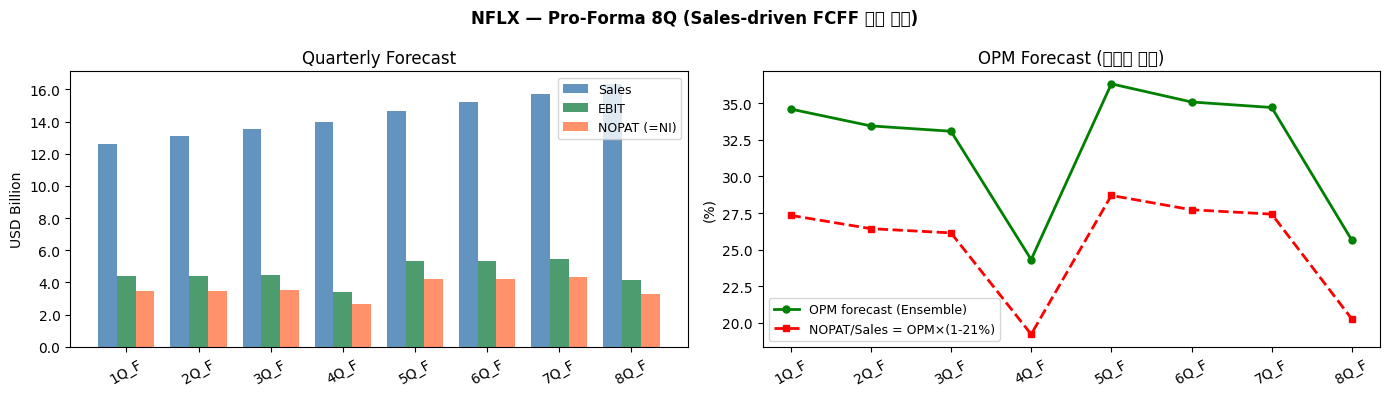

In [10]:
print(f"{'='*70}")
print(f"[{ticker}] Section C — Pro-Forma 분기 전망 ({FWD_QTRS}Q)")
print(f"  Sales model : {sales_model}")
print(f"  OPM model   : SARIMA+ETS+Theta Ensemble (DCFModel 동일)")
print(f"  Tax rate    : {tax*100:.1f}%")
print(f"{'='*70}")

if not pf.empty:
    # ── 피벗: rows=항목, cols=분기 레이블 ────────────────────────
    pf_pivot = pf.set_index("col_label")[["Sales", "EBIT", "NOPAT"]].T.copy()
    pf_pivot_B = (pf_pivot / 1e9).round(3)
    pf_pivot_B.index = ["Sales (B$)", "EBIT (B$)", "NOPAT=NI (B$)"]

    print("\n[단위: USD Billion]")
    display(pf_pivot_B)

    # 마진 행
    opm_row = (pf_pivot.loc["EBIT"]  / pf_pivot.loc["Sales"] * 100).round(1)
    npm_row = (pf_pivot.loc["NOPAT"] / pf_pivot.loc["Sales"] * 100).round(1)
    opm_row.name = "OPM_forecast (%)"
    npm_row.name = "NOPAT/Sales (%)"
    display(pd.concat([opm_row.to_frame().T, npm_row.to_frame().T]))

    print(f"\n  ※ NOPAT = EBIT × (1 - {tax*100:.1f}%)  — FCFF 계산의 NI 역할")
    print(f"     OPM은 과거 OPM 시계열을 SARIMA+ETS+Theta로 예측한 분기별 값입니다.")

    # ── 시각화 ────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"{ticker} — Pro-Forma {FWD_QTRS}Q (Sales-driven FCFF 동일 로직)",
                 fontsize=12, fontweight="bold")

    # Bar: Sales / EBIT / NOPAT
    ax = axes[0]
    qtrs = pf["col_label"].tolist()
    x = np.arange(len(qtrs))
    w = 0.26
    ax.bar(x - w,  pf["Sales"] / 1e9, w, label="Sales",      color="steelblue", alpha=0.85)
    ax.bar(x,      pf["EBIT"]  / 1e9, w, label="EBIT",       color="seagreen",  alpha=0.85)
    ax.bar(x + w,  pf["NOPAT"] / 1e9, w, label="NOPAT (=NI)", color="coral",    alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(qtrs, rotation=30)
    ax.set_ylabel("USD Billion"); ax.set_title("Quarterly Forecast")
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

    # Line: 분기별 OPM_forecast
    ax2 = axes[1]
    ax2.plot(qtrs, pf["OPM"] * 100, "g-o", linewidth=2, markersize=5,
             label="OPM forecast (Ensemble)")
    ax2.plot(qtrs, pf["NOPAT"] / pf["Sales"] * 100, "r--s", linewidth=2, markersize=5,
             label=f"NOPAT/Sales = OPM×(1-{tax*100:.0f}%)")
    ax2.set_xticks(range(len(qtrs))); ax2.set_xticklabels(qtrs, rotation=30)
    ax2.set_ylabel("(%)"); ax2.set_title("OPM Forecast (시계열 예측)")
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("Pro-Forma 계산 불가 (Sales 또는 OPM 예측 실패)")

## Cell 11 · Section D — DuPont & FCFF 구성요소 테이블

**rows: 분기 시계열  |  cols: Sales / OPM / EBIT / NOPAT / D&A / CapEx / NWC / ΔNWC / FCFF**

과거(12Q 실적) + 향후(8Q 예측) 연속 표시

In [11]:
print(f"{'='*70}")
print(f"[{ticker}] Section D — FCFF 구성요소 테이블")
print(f"  D&A={alpha:.4f}×Sales ({alpha_m})  "
      f"CapEx={beta:.4f}×Sales ({beta_m})  "
      f"NWC={gamma:.4f}×Sales ({gamma_m})")
print(f"{'='*70}")

def _fmt_fcff_table(df: pd.DataFrame, label_col: str) -> pd.DataFrame:
    """FCFF 구성요소 DataFrame 을 표시용으로 포맷"""
    disp = df.copy()
    for c in ["Sales", "EBIT", "NOPAT", "DA", "CapEx", "NWC", "ΔNWC", "FCFF"]:
        if c in disp.columns:
            disp[c] = (disp[c] / 1e9).round(3)
    if "OPM" in disp.columns:
        disp["OPM"] = (disp["OPM"] * 100).round(1)
    rename = {"Sales": "Sales(B$)", "EBIT": "EBIT(B$)", "NOPAT": "NOPAT(B$)",
              "DA": "D&A(B$)", "CapEx": "CapEx(B$)",
              "NWC": "NWC(B$)", "ΔNWC": "ΔNWC(B$)",
              "FCFF": "FCFF(B$)", "OPM": "OPM(%)"}
    disp = disp.rename(columns={k: v for k, v in rename.items() if k in disp.columns})
    return disp.set_index(label_col)

# ── 과거 (실적 기반) ──────────────────────────────────────────
if not hist_fcff.empty:
    print("\n[A] 과거 FCFF 구성요소 (실적 기반, 최근 12Q)")
    display(_fmt_fcff_table(hist_fcff, "quarter"))
else:
    print("[A] 과거 데이터 없음")

# ── 향후 (예측 기반) ──────────────────────────────────────────
if not pf.empty:
    print("\n[B] 향후 FCFF 구성요소 (예측 기반, 8Q)")
    display(_fmt_fcff_table(pf, "col_label"))
    print(f"\n  ※ 계산식 (DCFModel.compute_fcff 동일)")
    print(f"     EBIT  = Sales × OPM_forecast")
    print(f"     NOPAT = EBIT  × (1 - {tax*100:.1f}%)")
    print(f"     D&A   = {alpha:.4f} × Sales")
    print(f"     CapEx = {beta:.4f}  × Sales")
    print(f"     NWC   = {gamma:.4f} × Sales")
    print(f"     FCFF  = NOPAT + D&A - CapEx - ΔNWC")
else:
    print("[B] 예측 데이터 없음")

[NFLX] Section D — FCFF 구성요소 테이블
  D&A=0.3441×Sales (ols)  CapEx=0.0121×Sales (ols)  NWC=-1.2555×Sales (ols)

[A] 과거 FCFF 구성요소 (실적 기반, 최근 12Q)


,date,Sales(B$),OPM(%),EBIT(B$),NOPAT(B$),D&A(B$),CapEx(B$),NWC(B$),ΔNWC(B$),FCFF(B$),source,_da_src,_cx_src,_nwc_src
quarter,,,,,,,,,,,,,,
2023Q1,2023-03-31,8.162,21.0,1.714,1.354,3.550,0.062,-14.268,-1.546,6.389,actual,actual,actual,actual
2023Q2,2023-06-30,8.187,22.3,1.827,1.443,3.499,0.101,-15.562,-1.294,6.136,actual,actual,actual,actual
2023Q3,2023-09-30,8.542,22.4,1.916,1.514,3.664,0.104,-14.915,0.647,4.427,actual,actual,actual,actual
2023Q4,2023-12-31,8.833,16.9,1.496,1.182,3.841,0.082,-15.194,-0.279,5.220,actual,actual,actual,actual
2024Q1,2024-03-31,9.370,28.1,2.633,2.080,3.758,0.076,-15.117,0.077,5.685,actual,actual,actual,actual
2024Q2,2024-06-30,9.559,27.2,2.603,2.056,3.851,0.078,-14.548,0.570,5.259,actual,actual,actual,actual
2024Q3,2024-09-30,9.825,29.6,2.909,2.298,3.780,0.127,-15.911,-1.363,7.315,actual,actual,actual,actual
2024Q4,2024-12-31,10.247,22.2,2.273,1.795,4.241,0.159,-16.347,-0.436,6.314,actual,actual,actual,actual
2025Q1,2025-03-31,10.543,31.7,3.347,2.644,3.903,0.128,-15.475,0.872,5.547,actual,actual,actual,actual



[B] 향후 FCFF 구성요소 (예측 기반, 8Q)


,date,quarter,Sales(B$),OPM(%),EBIT(B$),NOPAT(B$),D&A(B$),CapEx(B$),NWC(B$),ΔNWC(B$),FCFF(B$),source
col_label,,,,,,,,,,,,
1Q_F,2026-03-31,2026Q1,12.624,34.6,4.369,3.452,4.344,0.153,-15.850,0.000,7.643,forecast
2Q_F,2026-06-30,2026Q2,13.072,33.5,4.374,3.455,4.498,0.158,-16.413,-0.562,8.358,forecast
3Q_F,2026-09-30,2026Q3,13.510,33.1,4.471,3.532,4.649,0.163,-16.962,-0.549,8.567,forecast
4Q_F,2026-12-31,2026Q4,14.001,24.3,3.405,2.690,4.818,0.169,-17.579,-0.617,7.956,forecast
5Q_F,2027-03-31,2027Q1,14.674,36.3,5.332,4.212,5.049,0.177,-18.424,-0.845,9.928,forecast
6Q_F,2027-06-30,2027Q2,15.204,35.1,5.336,4.215,5.232,0.184,-19.089,-0.666,9.929,forecast
7Q_F,2027-09-30,2027Q3,15.723,34.7,5.459,4.312,5.410,0.190,-19.741,-0.652,10.185,forecast
8Q_F,2027-12-31,2027Q4,16.306,25.6,4.179,3.302,5.611,0.197,-20.472,-0.731,9.447,forecast



  ※ 계산식 (DCFModel.compute_fcff 동일)
     EBIT  = Sales × OPM_forecast
     NOPAT = EBIT  × (1 - 21.0%)
     D&A   = 0.3441 × Sales
     CapEx = 0.0121  × Sales
     NWC   = -1.2555 × Sales
     FCFF  = NOPAT + D&A - CapEx - ΔNWC


## Cell 11-E2 · Section E-2 — 3-Stage DCF Decomposition & Validation

> EVA/Moat 기반 Phase2 기간 설정 근거, Phase별 연간 FCFF·PV·누적값, AR(1) 성장 경로를 표시합니다.


  [NFLX] Section E-2 · 3-Stage DCF Decomposition
  DB run_date = 2026-04-14   WACC = 13.7043%   g_term = 4.0000%

[0] EVA & Moat Classification
    ROIC (TTM)    : 32.85%
    WACC          : 13.70%
    EVA spread    : +19.15%
    n_positive    : 18/20 quarters (recent 20Q)
    Moat grade    : [Wide moat]
    → ρ (AR1)     : 0.8323  (EVA 기반 + OLS 보정, 전체 히스토리)
    → Phase2 dur  : 15 years
    → g0 (start)  : 43.03%  (최근 8Q CAGR, 전체 히스토리 기준)
    → hist FCFF Q : 40Q 사용 (tail 없음)

[1] Discount rate
    WACC          : 13.7043%
    g_terminal    : 4.0000%
    WACC - g      : 9.7043%

[2] Phase 1 - Forecast FCFF (Year 1~2)
    Year 1 (2026Q1~2026Q4)  FCFF=  32.524B  PV=  28.604B  Cum=  28.604B
    Year 2 (2027Q1~2027Q4)  FCFF=  39.488B  PV=  30.543B  Cum=  59.147B

[3] Phase 2 - Growth convergence (Year 3~17)
    Year  3  g= 36.5%  FCFF=  53.898B  PV=  36.664B  Cum=  95.811B
    Year  4  g= 31.0%  FCFF=  70.629B  PV=  42.255B  Cum= 138.066B
    Year  5  g= 26.5%  FCFF=  89.352B  PV=  47.013B

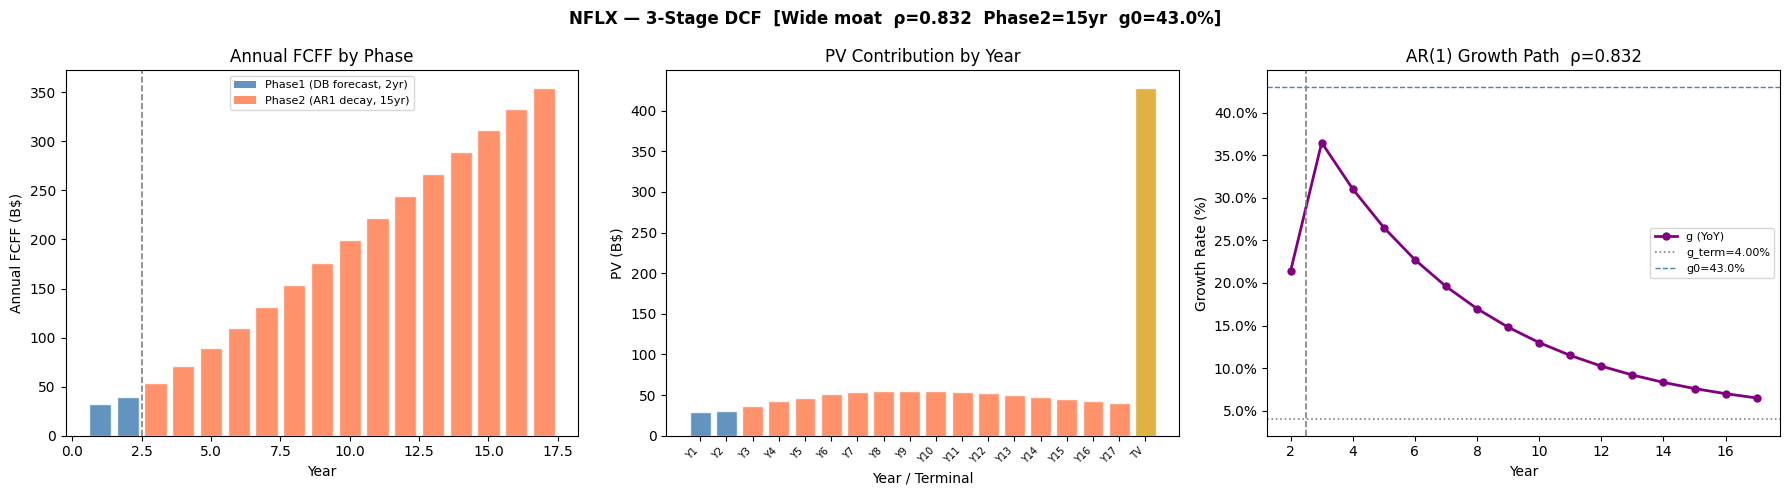


  [NFLX] Validation : DB vs Reconstructed
  DB  target_price  : $280.24   upside=171.7%
  Reconstructed EV  : $1215.283B
  (Net debt 차감 후 TP는 DB 저장값 참조)


In [12]:
# ═══════════════════════════════════════════════════════════════
#  Section E-2 · 3-Stage DCF Decomposition & Validation
#  ─ Purpose  : FCFF_DCF_Valuation_v7 (DB 저장값) 의 연간 FCFF
#               산출 근거를 Phase 1/2/3 로 분해해 표시.
#               EVA / Moat 기반 고성장 기간 설정 로직도 함께 검증.
#  ─ Requires : Cell 8 실행 완료 (sales_actual, sales_fc, opm_fc,
#               inc_df, bs_df, cf_df, tax, alpha, beta, gamma, pf)
#  ─ Key fix  : g0 추정 및 ρ OLS 보정 모두 전체 히스토리(tail 미적용)
#               사용 → FCFF_DCF_Valuation_v7._estimate_phase2_growth
#               와 완전히 동일한 로직
# ═══════════════════════════════════════════════════════════════

# ── 0. WACC / g_terminal ─────────────────────────────────────
if fcff_res is None:
    print("[Section E-2] FCFF DCF 결과 없음 (us_fcff_dcf_valuation 배치 필요)")
    raise SystemExit

_wacc      = fcff_res["wacc"]
_g_term    = fcff_res["g_terminal"]
_run_date  = fcff_res["run_date"]
_db_tp     = fcff_res["target_price"]
_db_up     = fcff_res["upside_pct"]
_db_df     = fcff_res["df"]

GDP_GROWTH = 0.04   # DCFModel.GDP_GROWTH 동일
SEP72      = "=" * 72

print(f"\n{SEP72}")
print(f"  [{ticker}] Section E-2 · 3-Stage DCF Decomposition")
print(f"  DB run_date = {_run_date}   WACC = {_wacc*100:.4f}%   g_term = {_g_term*100:.4f}%")
print(f"{SEP72}")

# ══════════════════════════════════════════════════════════════
#  STEP 1 · 전체 과거 FCFF 히스토리 계산
#           ★ tail 미적용 — DCFModel._compute_historical_fcff 동일
#             (g0 추정·ρ OLS 보정 모두 전체 기간이 필요)
# ══════════════════════════════════════════════════════════════
def _build_full_fcff_history(
    sales_act: pd.Series,
    inc: pd.DataFrame,
    tax_r: float,
    a: float, b: float, g: float,
) -> pd.Series:
    """
    전체 과거 분기 FCFF 시계열 반환 (pd.Series, index=date).
    DCFModel._compute_historical_fcff 와 동일 로직.
    tail() 제한 없음 — g0·ρ OLS 보정에 전체 데이터 사용.
    """
    _inc = inc.set_index("date")
    _rows, _prev = [], None
    for _dt, _s in sales_act.items():
        if pd.isna(_s) or _s <= 0:
            _prev = g * _s
            continue
        _op  = _inc["operatingIncome"].get(_dt, np.nan) if "operatingIncome" in _inc.columns else np.nan
        _rev = _inc["revenue"].get(_dt, np.nan)         if "revenue"          in _inc.columns else np.nan
        _opm = (float(_op) / float(_rev)
                if (pd.notna(_op) and pd.notna(_rev) and float(_rev) > 0)
                else np.nan)
        if pd.isna(_opm):
            _prev = g * _s
            continue
        _nopat = _s * _opm * (1 - tax_r)
        _nwc   = g * _s
        _dnwc  = (_nwc - _prev) if _prev is not None else 0.0
        _prev  = _nwc
        _rows.append((_dt, _nopat + a * _s - b * _s - _dnwc))
    if not _rows:
        return pd.Series(dtype=float)
    _idx, _vals = zip(*_rows)
    return pd.Series(list(_vals), index=list(_idx)).sort_index()

# 전체 히스토리 (tail 없음)
_fcff_history_full = _build_full_fcff_history(
    sales_actual, inc_df, tax, alpha, beta, gamma
)

# ══════════════════════════════════════════════════════════════
#  STEP 2 · EVA Spread 계산
#           DCFModel._compute_eva_spread 동일
# ══════════════════════════════════════════════════════════════
_inc_eva = inc_df[["date", "operatingIncome"]].copy()
_inc_eva["operatingIncome"] = pd.to_numeric(_inc_eva["operatingIncome"], errors="coerce")
_inc_eva["nopat_q"] = _inc_eva["operatingIncome"] * (1 - tax)
_inc_eva = _inc_eva.set_index("date").sort_index()

_bs_eva = bs_df.copy()
for _c in ["totalStockholdersEquity", "totalDebt", "cashAndCashEquivalents"]:
    if _c not in _bs_eva.columns:
        _bs_eva[_c] = 0.0
    _bs_eva[_c] = pd.to_numeric(_bs_eva[_c], errors="coerce").fillna(0)
_bs_eva["ic"] = (_bs_eva["totalStockholdersEquity"]
               + _bs_eva["totalDebt"]
               - _bs_eva["cashAndCashEquivalents"])
_bs_eva = _bs_eva.set_index("date")[["ic"]].sort_index()

_merged_eva = _bs_eva.join(_inc_eva[["nopat_q"]], how="inner").dropna()
_eva_series = []
_dates_eva  = sorted(_merged_eva.index)
for _i, _dt in enumerate(_dates_eva):
    if _i < 3:
        continue
    _nopat_ttm = float(_merged_eva["nopat_q"].iloc[_i-3:_i+1].sum())
    _ic_snap   = float(_merged_eva["ic"].iloc[_i])
    if _ic_snap <= 0:
        continue
    _eva_series.append({
        "date": _dt,
        "roic": _nopat_ttm / _ic_snap,
        "eva_spread": _nopat_ttm / _ic_snap - _wacc,
    })

_eva_roic   = _eva_series[-1]["roic"]       if _eva_series else np.nan
_eva_spread = _eva_series[-1]["eva_spread"] if _eva_series else np.nan
_n_pos      = sum(1 for e in _eva_series[-20:] if e["eva_spread"] > 0)

# ══════════════════════════════════════════════════════════════
#  STEP 3 · Moat 등급 → (ρ, Phase2 기간)
#           DCFModel._moat_to_rho_and_years 동일
# ══════════════════════════════════════════════════════════════
if np.isnan(_eva_spread):
    _rho, _n_ph2, _moat_label = 0.75, 8, "Unknown (fallback)"
elif _eva_spread > 0.15 and _n_pos >= 15:
    _rho, _n_ph2, _moat_label = 0.90, 15, "Wide moat"
elif _eva_spread > 0.08 and _n_pos >= 12:
    _rho, _n_ph2, _moat_label = 0.83, 12, "Narrow moat"
elif _eva_spread > 0.03 and _n_pos >= 8:
    _rho, _n_ph2, _moat_label = 0.75,  8, "Some moat"
else:
    _rho, _n_ph2, _moat_label = 0.60,  5, "No moat"

# ══════════════════════════════════════════════════════════════
#  STEP 4 · ρ OLS 보정
#           ★ _fcff_history_full 사용 (tail 미적용)
#             → DCFModel._estimate_phase2_growth OLS 보정과 동일
# ══════════════════════════════════════════════════════════════
_h_vals_full = _fcff_history_full.dropna().values
if len(_h_vals_full) >= 12:
    # 연간 합산 (4Q 단위)
    _ann_full = [float(np.sum(_h_vals_full[_y:_y+4]))
                 for _y in range(0, len(_h_vals_full) - len(_h_vals_full) % 4, 4)
                 if _y + 4 <= len(_h_vals_full)]
    if len(_ann_full) >= 4:
        _g_hist_full = [(_ann_full[_ii] / _ann_full[_ii-1] - 1)
                        for _ii in range(1, len(_ann_full))
                        if _ann_full[_ii-1] > 0 and _ann_full[_ii] > 0]
        if len(_g_hist_full) >= 3:
            _yt_ols = np.array([_g - GDP_GROWTH for _g in _g_hist_full[1:]])
            _xt_ols = np.array([_g - GDP_GROWTH for _g in _g_hist_full[:-1]])
            if np.dot(_xt_ols, _xt_ols) > 1e-10:
                _rho_ols = float(np.clip(
                    np.dot(_xt_ols, _yt_ols) / np.dot(_xt_ols, _xt_ols),
                    0.40, 0.92
                ))
                # EVA 기반 ρ와 OLS ρ의 가중 평균 (각 50%) — v7 동일
                _rho = float(np.clip(0.5 * _rho + 0.5 * _rho_ols, 0.40, 0.92))

# ══════════════════════════════════════════════════════════════
#  STEP 5 · g0 추정
#           ★ _fcff_history_full 사용 (tail 미적용)
#             → DCFModel._estimate_phase2_growth g0 추정과 동일
# ══════════════════════════════════════════════════════════════
_g0 = None
if len(_h_vals_full) >= 8:
    _f0 = float(_h_vals_full[-8])
    _fl = float(_h_vals_full[-1])
    if _f0 > 0 and _fl > 0:
        _cagr_q = (_fl / _f0) ** (4.0 / 8) - 1
        _g0 = float(np.clip((1 + _cagr_q) ** 4 - 1, GDP_GROWTH, 0.80))

# fallback: Phase1 연간 YoY
if _g0 is None and not pf.empty:
    _yr1_fcff = float(pf["FCFF"].iloc[:4].sum())
    _yr2_fcff = float(pf["FCFF"].iloc[4:8].sum()) if len(pf) >= 8 else _yr1_fcff
    _g0 = float(np.clip(_yr2_fcff / _yr1_fcff - 1, GDP_GROWTH, 0.80)) if _yr1_fcff > 0 else 0.10

if _g0 is None:
    _g0 = 0.10

# ══════════════════════════════════════════════════════════════
#  STEP 6 · Phase 2 AR(1) 성장 경로
#           g(t) = g_term + (g(t-1) - g_term) × ρ
# ══════════════════════════════════════════════════════════════
_g = _g0
_ph2_growth = []
for _ in range(_n_ph2):
    _g = GDP_GROWTH + (_g - GDP_GROWTH) * _rho
    _ph2_growth.append(float(np.clip(_g, GDP_GROWTH, 0.80)))

# ══════════════════════════════════════════════════════════════
#  STEP 7 · Phase 1 연간 합산 (DB 8Q 값 우선, pf fallback)
# ══════════════════════════════════════════════════════════════
_ph1_annual = []
if not _db_df.empty and "fcff" in _db_df.columns:
    _fcff_q_arr = pd.to_numeric(_db_df["fcff"], errors="coerce").fillna(0).values
    for _yr in range(0, len(_fcff_q_arr), 4):
        _ph1_annual.append(float(np.sum(_fcff_q_arr[_yr:_yr+4])))
elif not pf.empty:
    _fcff_q_arr = pf["FCFF"].values
    for _yr in range(0, len(_fcff_q_arr), 4):
        _ph1_annual.append(float(np.sum(_fcff_q_arr[_yr:_yr+4])))

if not _ph1_annual:
    print("[E-2] Phase1 FCFF 계산 불가 — DB 및 pf 모두 비어 있음")
    raise SystemExit

# ══════════════════════════════════════════════════════════════
#  STEP 8 · Phase 2 연간 FCFF / PV 계산
# ══════════════════════════════════════════════════════════════
_ph2_annual = []
_last_f = float(_ph1_annual[-1])
for _gg in _ph2_growth:
    _last_f = _last_f * (1 + _gg)
    _ph2_annual.append(_last_f)

_all_annual    = _ph1_annual + _ph2_annual
_T_total       = len(_all_annual)
_fcff_last_ann = float(_ph2_annual[-1])

_pv_fcff = sum(_all_annual[_t] / (1 + _wacc) ** (_t + 1) for _t in range(_T_total))
_tv      = _fcff_last_ann * (1 + _g_term) / (_wacc - _g_term)
_pv_tv   = _tv / (1 + _wacc) ** _T_total
_ev_recon = _pv_fcff + _pv_tv

# ══════════════════════════════════════════════════════════════
#  PRINT [0] EVA & Moat
# ══════════════════════════════════════════════════════════════
print(f"\n[0] EVA & Moat Classification")
print(f"    ROIC (TTM)    : {_eva_roic:.2%}"    if not np.isnan(_eva_roic)   else "    ROIC (TTM)    : N/A")
print(f"    WACC          : {_wacc:.2%}")
print(f"    EVA spread    : {_eva_spread:+.2%}" if not np.isnan(_eva_spread) else "    EVA spread    : N/A")
print(f"    n_positive    : {_n_pos}/20 quarters (recent 20Q)")
print(f"    Moat grade    : [{_moat_label}]")
print(f"    → ρ (AR1)     : {_rho:.4f}  (EVA 기반 + OLS 보정, 전체 히스토리)")
print(f"    → Phase2 dur  : {_n_ph2} years")
print(f"    → g0 (start)  : {_g0:.2%}  (최근 8Q CAGR, 전체 히스토리 기준)")
print(f"    → hist FCFF Q : {len(_h_vals_full)}Q 사용 (tail 없음)")

# ══════════════════════════════════════════════════════════════
#  PRINT [1] Discount rate
# ══════════════════════════════════════════════════════════════
print(f"\n[1] Discount rate")
print(f"    WACC          : {_wacc*100:.4f}%")
print(f"    g_terminal    : {_g_term*100:.4f}%")
print(f"    WACC - g      : {(_wacc - _g_term)*100:.4f}%")

# ══════════════════════════════════════════════════════════════
#  PRINT [2] Phase 1
# ══════════════════════════════════════════════════════════════
print(f"\n[2] Phase 1 - Forecast FCFF (Year 1~{len(_ph1_annual)})")
_cum = 0.0
for _t, _f in enumerate(_ph1_annual, 1):
    _pv = _f / (1 + _wacc) ** _t
    _cum += _pv
    if not _db_df.empty and "quarter" in _db_df.columns:
        _qs = _db_df["quarter"].tolist()
        _q0 = _qs[(_t-1)*4]               if (_t-1)*4 < len(_qs) else "?"
        _q1 = _qs[min(_t*4-1, len(_qs)-1)]
        _ql = f"({_q0}~{_q1})"
    else:
        _ql = ""
    print(f"    Year {_t} {_ql}  FCFF={_f/1e9:>8.3f}B  PV={_pv/1e9:>8.3f}B  Cum={_cum/1e9:>8.3f}B")

# ══════════════════════════════════════════════════════════════
#  PRINT [3] Phase 2
# ══════════════════════════════════════════════════════════════
print(f"\n[3] Phase 2 - Growth convergence (Year {len(_ph1_annual)+1}~{_T_total})")
for _t_off, (_f2, _gg2) in enumerate(zip(_ph2_annual, _ph2_growth), 1):
    _yr2 = len(_ph1_annual) + _t_off
    _pv2 = _f2 / (1 + _wacc) ** _yr2
    _cum += _pv2
    print(f"    Year {_yr2:>2}  g={_gg2*100:>5.1f}%  "
          f"FCFF={_f2/1e9:>8.3f}B  PV={_pv2/1e9:>8.3f}B  Cum={_cum/1e9:>8.3f}B")

# ══════════════════════════════════════════════════════════════
#  PRINT [4] Terminal Value
# ══════════════════════════════════════════════════════════════
print(f"\n[4] Phase 3 - Terminal Value")
print(f"    Last annual FCFF : ${_fcff_last_ann/1e9:.3f}B")
print(f"    TV = {_fcff_last_ann/1e9:.3f}B x {1+_g_term:.4f} / {_wacc-_g_term:.4f} = ${_tv/1e9:.3f}B")
print(f"    PV(TV) = TV / (1+WACC)^{_T_total} = ${_pv_tv/1e9:.3f}B")

# ══════════════════════════════════════════════════════════════
#  PRINT [5] EV Breakdown
# ══════════════════════════════════════════════════════════════
_fcff_wt = _pv_fcff / _ev_recon * 100 if _ev_recon != 0 else np.nan
print(f"\n[5] EV Breakdown")
print(f"    PV(Phase1+2 FCFF) = ${_pv_fcff/1e9:.3f}B  ({_fcff_wt:.1f}%)")
print(f"    PV(TV)            = ${_pv_tv/1e9:.3f}B  ({100-_fcff_wt:.1f}%)")
print(f"    Reconstructed EV  = ${_ev_recon/1e9:.3f}B")

# ══════════════════════════════════════════════════════════════
#  CHART (1×3)
# ══════════════════════════════════════════════════════════════
_fig, _axes = plt.subplots(1, 3, figsize=(18, 5))
_fig.suptitle(
    f"{ticker} — 3-Stage DCF  [{_moat_label}  ρ={_rho:.3f}  Phase2={_n_ph2}yr  g0={_g0:.1%}]",
    fontsize=12, fontweight="bold"
)

# Chart 1: Annual FCFF by Phase
_ax1 = _axes[0]
_n_ph1 = len(_ph1_annual)
_all_b  = [f / 1e9 for f in _all_annual]
_colors1 = (["steelblue"] * _n_ph1) + (["coral"] * len(_ph2_annual))
_ax1.bar(range(1, _T_total + 1), _all_b, color=_colors1, alpha=0.85, edgecolor="white")
if _n_ph1 < _T_total:
    _ax1.axvline(_n_ph1 + 0.5, color="gray", linestyle="--", linewidth=1.2)
_ax1.set_xlabel("Year"); _ax1.set_ylabel("Annual FCFF (B$)")
_ax1.set_title("Annual FCFF by Phase")
_ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
from matplotlib.patches import Patch
_ax1.legend(handles=[
    Patch(facecolor="steelblue", alpha=0.85, label=f"Phase1 (DB forecast, {_n_ph1}yr)"),
    Patch(facecolor="coral",     alpha=0.85, label=f"Phase2 (AR1 decay, {len(_ph2_annual)}yr)"),
], fontsize=8)

# Chart 2: PV Contribution
_ax2 = _axes[1]
_pv_list2 = [_all_annual[t] / (1 + _wacc) ** (t + 1) / 1e9 for t in range(_T_total)]
_pv_list2.append(_pv_tv / 1e9)
_labels2  = [f"Y{t+1}" for t in range(_T_total)] + ["TV"]
_colors2  = (["steelblue"] * _n_ph1 + ["coral"] * len(_ph2_annual) + ["goldenrod"])
_ax2.bar(_labels2, _pv_list2, color=_colors2, alpha=0.85, edgecolor="white")
_ax2.set_title("PV Contribution by Year")
_ax2.set_ylabel("PV (B$)"); _ax2.set_xlabel("Year / Terminal")
plt.setp(_ax2.get_xticklabels(), rotation=45, ha="right", fontsize=7)

# Chart 3: AR(1) Growth Path
_ax3 = _axes[2]
_yr_all3 = list(range(1, _T_total + 1))
_g_ph1_list = [np.nan] + [(_ph1_annual[_ii] / _ph1_annual[_ii-1] - 1)
                           if _ph1_annual[_ii-1] > 0 else np.nan
                           for _ii in range(1, len(_ph1_annual))]
_g_all3 = _g_ph1_list + _ph2_growth
_g_pct3 = [g * 100 if (g is not None and not np.isnan(g)) else np.nan for g in _g_all3]
_yr_valid = [y for y, g in zip(_yr_all3, _g_pct3) if not np.isnan(g)]
_g_valid  = [g for g in _g_pct3 if not np.isnan(g)]
_ax3.plot(_yr_valid, _g_valid, "o-", color="purple", linewidth=2, markersize=5, label="g (YoY)")
_ax3.axhline(GDP_GROWTH * 100, color="gray", linestyle=":", linewidth=1.2,
             label=f"g_term={_g_term*100:.2f}%")
_ax3.axhline(_g0 * 100, color="steelblue", linestyle="--", linewidth=1.0,
             label=f"g0={_g0*100:.1f}%")
if _n_ph1 < _T_total:
    _ax3.axvline(_n_ph1 + 0.5, color="gray", linestyle="--", linewidth=1.2)
_ax3.set_xlabel("Year"); _ax3.set_ylabel("Growth Rate (%)")
_ax3.set_title(f"AR(1) Growth Path  ρ={_rho:.3f}")
_ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
_ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════
#  Validation
# ══════════════════════════════════════════════════════════════
print(f"\n{SEP72}")
print(f"  [{ticker}] Validation : DB vs Reconstructed")
print(f"{SEP72}")
print(f"  DB  target_price  : ${_db_tp:.2f}   upside={_db_up:.1f}%")
print(f"  Reconstructed EV  : ${_ev_recon/1e9:.3f}B")
print(f"  (Net debt 차감 후 TP는 DB 저장값 참조)")


## Cell 12 · Section E — 상대가치 멀티플 근거 테이블 (PBR / PER / PSR)

In [13]:
print(f"{'='*70}")
print(f"[{ticker}] Section E — 상대가치 멀티플 근거")
print(f"{'='*70}")

if rel_res:
    r = rel_res

    # ── E-1: DuPont 2yr 예측 ──────────────────────────────────
    dupont_fwd = pd.DataFrame({
        "구분":         ["Year +1",    "Year +2"],
        "Sales (B$)":  [f"{(r.get('sales_y1') or np.nan)/1e9:.3f}",
                        f"{(r.get('sales_y2') or np.nan)/1e9:.3f}"],
        "NPM (%)": [f"{(r.get('npm_y1') or np.nan)*100:.1f}",
                    f"{(r.get('npm_y2') or np.nan)*100:.1f}"],
        "Asset TO":    [f"{r.get('at_y1') or np.nan:.3f}",
                        f"{r.get('at_y2') or np.nan:.3f}"],
        "Leverage":    [f"{r.get('fl_y1') or np.nan:.2f}",
                        f"{r.get('fl_y2') or np.nan:.2f}"],
        "ROE (%)": [f"{(r.get('roe_y1') or np.nan)*100:.1f}",
                    f"{(r.get('roe_y2') or np.nan)*100:.1f}"],
    })
    print("\n[DuPont 2yr 예측 — 멀티플 산출 근거]")
    display(dupont_fwd.set_index("구분"))

    # ── E-2: Beta / Re ────────────────────────────────────────
    re_mid   = float(r.get("re_mid")  or np.nan)
    roe_y2   = float(r.get("roe_y2") or np.nan)
    g_est    = float(r.get("g_est")  or np.nan)
    npm_y2   = float(r.get("npm_y2") or np.nan)
    pbr_th   = float(r.get("pbr_theory") or np.nan)
    psr_th   = float(r.get("psr_theory") or np.nan)
    per_th   = float(r.get("per_theory") or np.nan)

    beta_df = pd.DataFrame([
        {"구분": "Raw Beta",     "값": f"{r.get('beta_raw') or np.nan:.3f}"},
        {"구분": "Blume Adj.",   "값": f"{r.get('beta_blume') or np.nan:.3f}"},
        {"구분": "Sector Beta",  "값": f"{r.get('beta_sector') or np.nan:.3f}"},
        {"구분": "Ensemble Beta","값": f"{r.get('beta_ensemble') or np.nan:.3f}"},
        {"구분": "Re (Low)",     "값": f"{(r.get('re_low') or np.nan)*100:.2f}%"},
        {"구분": "Re (Mid)",     "값": f"{(r.get('re_mid') or np.nan)*100:.2f}%"},
        {"구분": "Re (High)",    "값": f"{(r.get('re_high') or np.nan)*100:.2f}%"},
        {"구분": "g_est",        "값": f"{g_est*100:.1f}%" if not np.isnan(g_est) else "N/A"},
    ])
    print("\n[Beta & 할인율]")
    display(beta_df.set_index("구분"))

    # ── E-3: 이론 멀티플 산출 근거 ────────────────────────────
    formula_df = pd.DataFrame([
        {"멀티플": "PBR",
         "공식":         "(ROE - g) / (Re - g)",
         "ROE_y2 (%)": f"{roe_y2*100:.1f}" if not np.isnan(roe_y2) else "N/A",
         "g_est (%)": f"{g_est*100:.1f}"   if not np.isnan(g_est)  else "N/A",
         "Re_mid (%)": f"{re_mid*100:.2f}" if not np.isnan(re_mid) else "N/A",
         "이론 멀티플": f"{pbr_th:.2f}x"   if not np.isnan(pbr_th) else "N/A"},
        {"멀티플": "PSR",
         "공식":         "NPM×(1-payout) / (Re - g)",
         "ROE_y2 (%)": f"{roe_y2*100:.1f}" if not np.isnan(roe_y2) else "N/A",
         "g_est (%)": f"{g_est*100:.1f}"   if not np.isnan(g_est)  else "N/A",
         "Re_mid (%)": f"{re_mid*100:.2f}" if not np.isnan(re_mid) else "N/A",
         "이론 멀티플": f"{psr_th:.2f}x"   if not np.isnan(psr_th) else "N/A"},
        {"멀티플": "PER",
         "공식":         "PBR / ROE",
         "ROE_y2 (%)": f"{roe_y2*100:.1f}" if not np.isnan(roe_y2) else "N/A",
         "g_est (%)": f"{g_est*100:.1f}"   if not np.isnan(g_est)  else "N/A",
         "Re_mid (%)": f"{re_mid*100:.2f}" if not np.isnan(re_mid) else "N/A",
         "이론 멀티플": f"{per_th:.2f}x"   if not np.isnan(per_th) else "N/A"},
    ])
    print("\n[이론 멀티플 산출 근거 — Gordon Growth Model]")
    display(formula_df.set_index("멀티플"))

    # ── E-4: 이론 vs 실제 멀티플 & 적정주가 ──────────────────
    multi_comp = pd.DataFrame([
        {"멀티플": "PBR",
         "이론값": f"{pbr_th:.2f}x"  if not np.isnan(pbr_th) else "N/A",
         "실제값": f"{float(r.get('actual_pbr') or np.nan):.2f}x",
         "적정주가($)": f"{float(r.get('tp_pbr') or np.nan):.2f}",
         "업사이드(%)": f"{float(r.get('upside_pbr') or np.nan):.1f}"},
        {"멀티플": "PER",
         "이론값": f"{per_th:.2f}x"  if not np.isnan(per_th) else "N/A",
         "실제값": f"{float(r.get('actual_per') or np.nan):.2f}x",
         "적정주가($)": f"{float(r.get('tp_per') or np.nan):.2f}",
         "업사이드(%)": f"{float(r.get('upside_per') or np.nan):.1f}"},
        {"멀티플": "PSR",
         "이론값": f"{psr_th:.2f}x"  if not np.isnan(psr_th) else "N/A",
         "실제값": f"{float(r.get('actual_psr') or np.nan):.2f}x",
         "적정주가($)": f"{float(r.get('tp_psr') or np.nan):.2f}",
         "업사이드(%)": f"{float(r.get('upside_psr') or np.nan):.1f}"},
    ])
    print("\n[이론 vs 실제 멀티플 & 적정주가]")
    display(multi_comp.set_index("멀티플"))
else:
    print("상대가치 결과 없음 — Relative_Valuation_v3 배치 실행 후 재확인")

[NFLX] Section E — 상대가치 멀티플 근거

[DuPont 2yr 예측 — 멀티플 산출 근거]


,Sales (B$),NPM (%),Asset TO,Leverage,ROE (%)
구분,,,,,
Year +1,53.208,28.3,0.651,3.33,61.3
Year +2,61.907,28.3,0.651,3.33,61.3



[Beta & 할인율]


,값
구분,
Raw Beta,0.900
Blume Adj.,0.933
Sector Beta,0.900
Ensemble Beta,0.920
Re (Low),8.46%
Re (Mid),9.56%
Re (High),10.66%
g_est,8.0%



[이론 멀티플 산출 근거 — Gordon Growth Model]


,공식,ROE_y2 (%),g_est (%),Re_mid (%),이론 멀티플
멀티플,,,,,
PBR,(ROE - g) / (Re - g),61.3,8.0,9.56,22.64x
PSR,NPM×(1-payout) / (Re - g),61.3,8.0,9.56,10.44x
PER,PBR / ROE,61.3,8.0,9.56,36.95x



[이론 vs 실제 멀티플 & 적정주가]


,이론값,실제값,적정주가($),업사이드(%)
멀티플,,,,
PBR,22.64x,12.66x,184.40,78.7
PER,36.95x,25.46x,149.74,45.1
PSR,10.44x,7.19x,149.74,45.1


## Cell 13 · Section F — 적정주가 비교 시각화

[NFLX] Section F — 적정주가 비교


,Target Price ($),Upside (%)
Method,,
Current,103.16,-
FCFF DCF,280.24,171.7
PBR,184.40,78.7
PER,149.74,45.1
PSR,149.74,45.1
Avg(PBR/PER/PSR),161.29,56.3


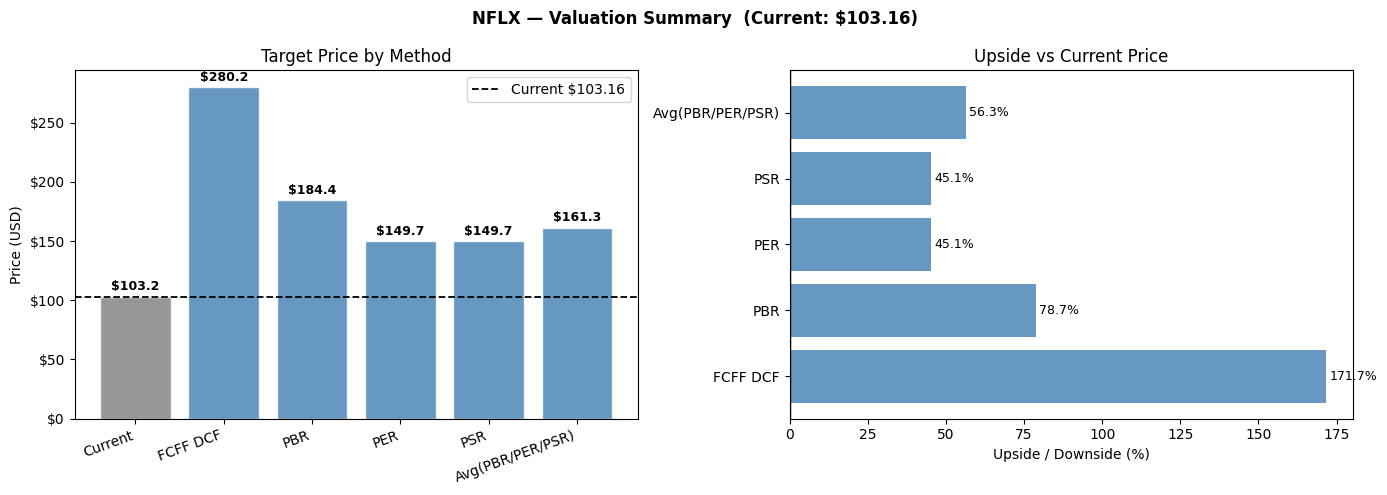

In [14]:
print(f"{'='*70}")
print(f"[{ticker}] Section F — 적정주가 비교")
print(f"{'='*70}")

tp_data = {"Current": current_price}
if fcff_res and not np.isnan(fcff_res.get("target_price", np.nan)):
    tp_data["FCFF DCF"] = fcff_res["target_price"]
if rel_res:
    for key, label in [("tp_pbr", "PBR"), ("tp_per", "PER"),
                        ("tp_psr", "PSR"), ("tp_avg", "Avg(PBR/PER/PSR)")]:
        v = rel_res.get(key)
        if v and not np.isnan(float(v)):
            tp_data[label] = float(v)

# 요약 테이블
cp = tp_data.get("Current", np.nan)
summary_rows = []
for name, tp in tp_data.items():
    upside = (tp / cp - 1) * 100 if (not np.isnan(cp) and cp > 0 and name != "Current") else np.nan
    summary_rows.append({"Method": name,
                         "Target Price ($)": round(tp, 2),
                         "Upside (%)": round(upside, 1) if not np.isnan(upside) else "-"})
display(pd.DataFrame(summary_rows).set_index("Method"))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"{ticker} — Valuation Summary  (Current: ${cp:.2f})",
             fontsize=12, fontweight="bold")

ax1 = axes[0]
labels = list(tp_data.keys())
values = list(tp_data.values())
colors = ["gray" if l == "Current" else
          ("steelblue" if v > cp else "tomato")
          for l, v in zip(labels, values)]
bars = ax1.bar(labels, values, color=colors, alpha=0.82, edgecolor="white")
ax1.axhline(cp, color="black", linestyle="--", linewidth=1.3,
            label=f"Current ${cp:.2f}")
for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             val + max(values) * 0.01,
             f"${val:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax1.set_ylabel("Price (USD)")
ax1.set_title("Target Price by Method")
ax1.legend()
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
plt.setp(ax1.get_xticklabels(), rotation=20, ha="right")

ax2 = axes[1]
upside_data = [(name, (v / cp - 1) * 100)
               for name, v in tp_data.items()
               if name != "Current" and not np.isnan(cp) and cp > 0]
if upside_data:
    names_up, upsides = zip(*upside_data)
    bar_colors = ["steelblue" if u >= 0 else "tomato" for u in upsides]
    y_pos = np.arange(len(names_up))
    ax2.barh(y_pos, upsides, color=bar_colors, alpha=0.82)
    ax2.axvline(0, color="black", linewidth=1.0)
    ax2.set_yticks(y_pos); ax2.set_yticklabels(names_up)
    ax2.set_xlabel("Upside / Downside (%)")
    ax2.set_title("Upside vs Current Price")
    for y, u in zip(y_pos, upsides):
        ax2.text(u + (1 if u >= 0 else -1), y, f"{u:.1f}%",
                 va="center", ha=("left" if u >= 0 else "right"), fontsize=9)

plt.tight_layout()
plt.show()

## Cell 14 · Section G — 예측 시각화 (4분할)

Sales · EBIT/NOPAT · OPM · FCFF — 과거(실적) + 향후(예측) 연속 시계열

[NFLX] Section G — 예측 시각화


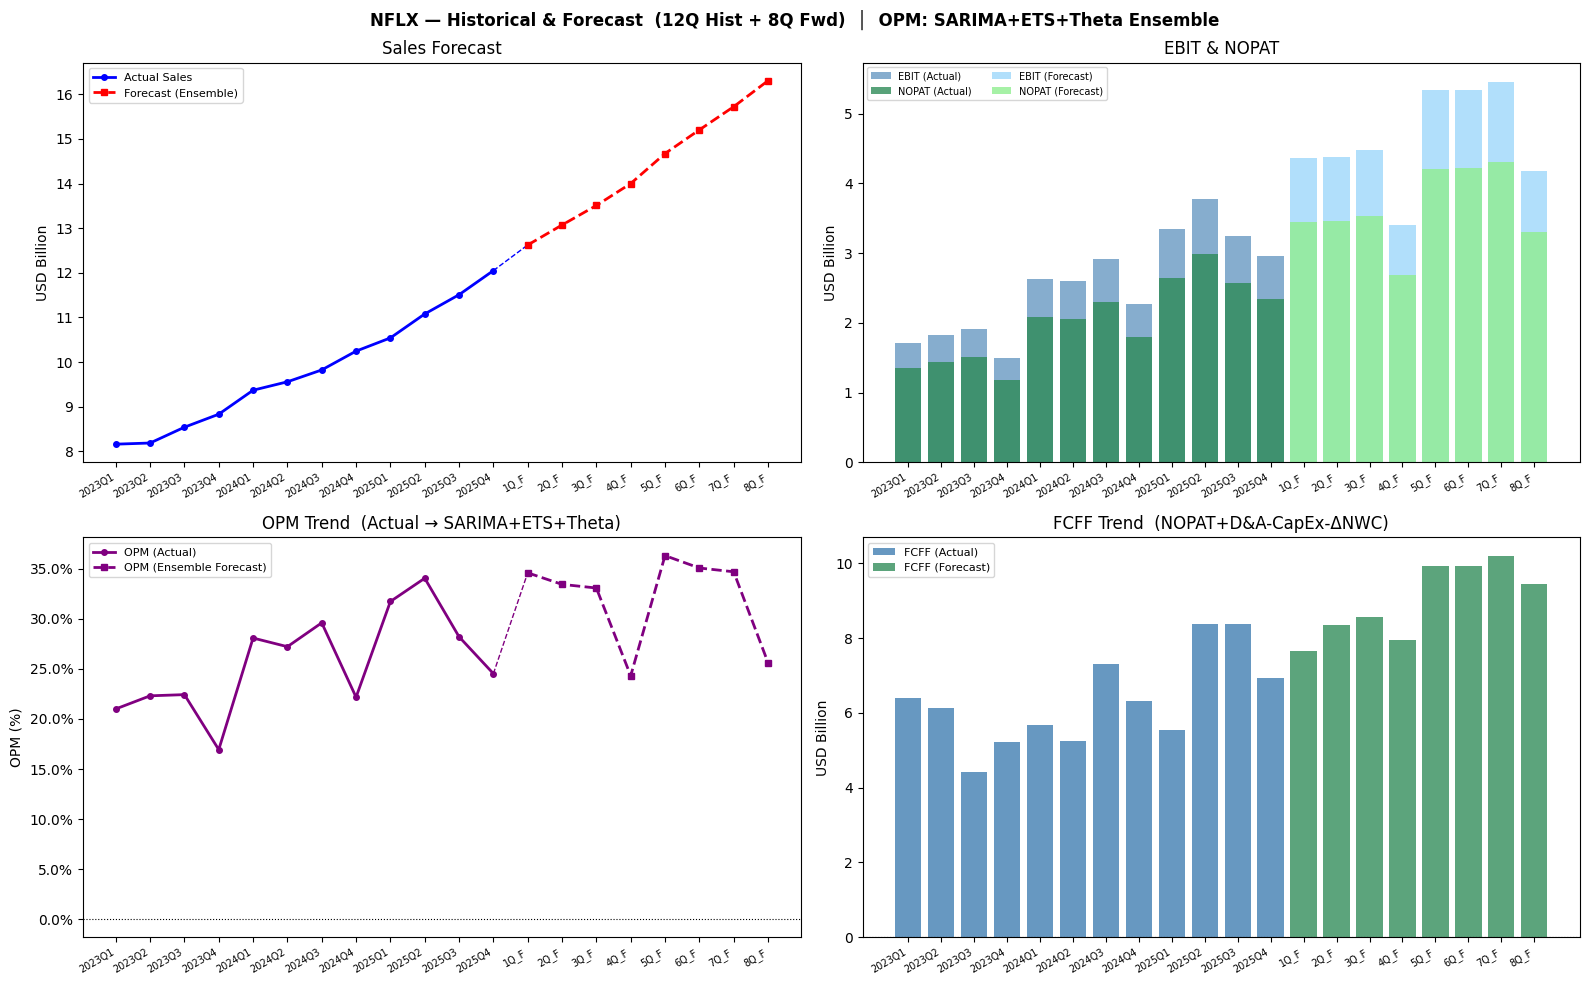

In [15]:
print(f"{'='*70}")
print(f"[{ticker}] Section G — 예측 시각화")
print(f"{'='*70}")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    f"{ticker} — Historical & Forecast  "
    f"({HIST_QTRS}Q Hist + {FWD_QTRS}Q Fwd)  "
    f"│  OPM: SARIMA+ETS+Theta Ensemble",
    fontsize=12, fontweight="bold"
)

def _qlabels(dates):
    return [f"{d.year}Q{d.quarter}" for d in dates]

# ── G-1: Sales (실적 + 예측) ─────────────────────────────────
ax = axes[0, 0]
if not hist_fcff.empty:
    h_q = hist_fcff["quarter"].tolist()
    h_s = (hist_fcff["Sales"] / 1e9).tolist()
    ax.plot(h_q, h_s, "b-o", lw=2, ms=4, label="Actual Sales")
if not pf.empty:
    f_q = pf["col_label"].tolist()
    f_s = (pf["Sales"] / 1e9).tolist()
    if not hist_fcff.empty:
        ax.plot([h_q[-1], f_q[0]], [h_s[-1], f_s[0]], "b--", lw=1)
    ax.plot(f_q, f_s, "r--s", lw=2, ms=4, label=f"Forecast ({sales_model})")
ax.set_title("Sales Forecast"); ax.set_ylabel("USD Billion")
ax.legend(fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=7)

# ── G-2: EBIT / NOPAT ────────────────────────────────────────
ax2 = axes[0, 1]
if not hist_fcff.empty:
    ax2.bar(hist_fcff["quarter"], hist_fcff["EBIT"]  / 1e9,
            color="steelblue", alpha=0.65, label="EBIT (Actual)")
    ax2.bar(hist_fcff["quarter"], hist_fcff["NOPAT"] / 1e9,
            color="seagreen", alpha=0.80, label="NOPAT (Actual)")
if not pf.empty:
    ax2.bar(pf["col_label"], pf["EBIT"]  / 1e9,
            color="lightskyblue", alpha=0.65, label="EBIT (Forecast)")
    ax2.bar(pf["col_label"], pf["NOPAT"] / 1e9,
            color="lightgreen", alpha=0.80, label="NOPAT (Forecast)")
ax2.set_title("EBIT & NOPAT"); ax2.set_ylabel("USD Billion")
ax2.legend(fontsize=7, ncol=2)
plt.setp(ax2.get_xticklabels(), rotation=30, ha="right", fontsize=7)

# ── G-3: OPM 시계열 (실적 vs 예측) ───────────────────────────
ax3 = axes[1, 0]
if not hist_fcff.empty:
    ax3.plot(hist_fcff["quarter"], hist_fcff["OPM"] * 100,
             "purple", marker="o", lw=2, ms=4, label="OPM (Actual)")
if not pf.empty:
    if not hist_fcff.empty:
        ax3.plot([hist_fcff["quarter"].iloc[-1], pf["col_label"].iloc[0]],
                 [hist_fcff["OPM"].iloc[-1] * 100, pf["OPM"].iloc[0] * 100],
                 "purple", lw=1, ls="--")
    ax3.plot(pf["col_label"], pf["OPM"] * 100,
             "purple", marker="s", lw=2, ms=4, ls="--",
             label="OPM (Ensemble Forecast)")
ax3.axhline(0, color="black", lw=0.8, ls=":")
ax3.set_title("OPM Trend  (Actual → SARIMA+ETS+Theta)")
ax3.set_ylabel("OPM (%)")
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax3.legend(fontsize=8)
plt.setp(ax3.get_xticklabels(), rotation=30, ha="right", fontsize=7)

# ── G-4: FCFF 시계열 ──────────────────────────────────────────
ax4 = axes[1, 1]
if not hist_fcff.empty:
    h_fcff = hist_fcff["FCFF"] / 1e9
    colors_h = ["steelblue" if v >= 0 else "tomato" for v in h_fcff]
    ax4.bar(hist_fcff["quarter"], h_fcff, color=colors_h,
            alpha=0.82, label="FCFF (Actual)")
if not pf.empty:
    f_fcff = pf["FCFF"] / 1e9
    colors_f = ["seagreen" if v >= 0 else "tomato" for v in f_fcff]
    ax4.bar(pf["col_label"], f_fcff, color=colors_f,
            alpha=0.78, label="FCFF (Forecast)")
ax4.axhline(0, color="black", lw=0.8, ls=":")
ax4.set_title("FCFF Trend  (NOPAT+D&A-CapEx-ΔNWC)")
ax4.set_ylabel("USD Billion")
ax4.legend(fontsize=8)
plt.setp(ax4.get_xticklabels(), rotation=30, ha="right", fontsize=7)

plt.tight_layout()
plt.show()

## Cell 15 · Investment Summary Card

In [16]:
print(f"{'='*70}")
print(f"  INVESTMENT SUMMARY — {ticker}")
print(f"  As of: {datetime.now().strftime('%Y-%m-%d')}")
print(f"{'='*70}")

print(f"\n  Current Price   : ${current_price:.2f}")

print(f"\n  [Intrinsic Value — FCFF DCF]")
if fcff_res:
    print(f"    Target Price  : ${fcff_res.get('target_price', np.nan):.2f}")
    print(f"    Upside        : {fcff_res.get('upside_pct', np.nan):.1f}%")
    print(f"    WACC          : {fcff_res.get('wacc', np.nan)*100:.2f}%")
    print(f"    g_terminal    : {fcff_res.get('g_terminal', np.nan)*100:.2f}%")
else:
    print("    → 결과 없음 (us_fcff_dcf_valuation 배치 필요)")

print(f"\n  [Relative Valuation — PBR / PER / PSR]")
if rel_res:
    for method, tp_key, up_key in [
        ("PBR", "tp_pbr", "upside_pbr"), ("PER", "tp_per", "upside_per"),
        ("PSR", "tp_psr", "upside_psr"), ("Avg", "tp_avg", "upside_avg"),
    ]:
        try:
            tp_v = float(rel_res.get(tp_key) or np.nan)
            up_v = float(rel_res.get(up_key) or np.nan)
        except (ValueError, TypeError):
            tp_v = up_v = np.nan
        tp_str = f"${tp_v:.2f}" if not np.isnan(tp_v) else "N/A"
        up_str = f"{up_v:.1f}%" if not np.isnan(up_v) else "N/A"
        print(f"    {method:<5} TP: {tp_str:<10}  Upside: {up_str}")
else:
    print("    → 결과 없음 (us_relative_valuation 배치 필요)")

print(f"\n  [Forward Pro-Forma (8Q Avg)]")
if not pf.empty:
    avg_sales = pf["Sales"].mean() / 1e9
    avg_opm   = pf["OPM"].mean()  * 100
    avg_nopat = pf["NOPAT"].mean()/ 1e9
    avg_fcff  = pf["FCFF"].mean() / 1e9
    print(f"    Sales/Q   : ${avg_sales:.3f}B    OPM: {avg_opm:.1f}%")
    print(f"    NOPAT/Q   : ${avg_nopat:.3f}B   FCFF/Q: ${avg_fcff:.3f}B")
    print(f"    Sales mdl : {sales_model}")
    print(f"    OPM mdl   : SARIMA+ETS+Theta Ensemble")

print(f"\n  [파라미터 (DCFModel 동일)]")
print(f"    Tax rate  : {tax*100:.1f}%")
print(f"    D&A/Sales : {alpha:.4f}  ({alpha_m})")
print(f"    CapEx/S   : {beta:.4f}  ({beta_m})")
print(f"    NWC/S     : {gamma:.4f}  ({gamma_m})")

print(f"\n{'='*70}")
print(f"  ※ FCFF/상대가치 적정주가는 배치 결과(DB)를 읽어온 값입니다.")
print(f"    Pro-Forma는 이 보고서에서 DCFModel 동일 로직으로 실시간 재계산합니다.")
print(f"{'='*70}")

  INVESTMENT SUMMARY — NFLX
  As of: 2026-04-14

  Current Price   : $103.16

  [Intrinsic Value — FCFF DCF]
    Target Price  : $280.24
    Upside        : 171.7%
    WACC          : 13.70%
    g_terminal    : 4.00%

  [Relative Valuation — PBR / PER / PSR]
    PBR   TP: $184.40     Upside: 78.7%
    PER   TP: $149.74     Upside: 45.1%
    PSR   TP: $149.74     Upside: 45.1%
    Avg   TP: $161.29     Upside: 56.3%

  [Forward Pro-Forma (8Q Avg)]
    Sales/Q   : $14.389B    OPM: 32.2%
    NOPAT/Q   : $3.646B   FCFF/Q: $9.002B
    Sales mdl : Ensemble
    OPM mdl   : SARIMA+ETS+Theta Ensemble

  [파라미터 (DCFModel 동일)]
    Tax rate  : 21.0%
    D&A/Sales : 0.3441  (ols)
    CapEx/S   : 0.0121  (ols)
    NWC/S     : -1.2555  (ols)

  ※ FCFF/상대가치 적정주가는 배치 결과(DB)를 읽어온 값입니다.
    Pro-Forma는 이 보고서에서 DCFModel 동일 로직으로 실시간 재계산합니다.


## Cell 16 · Section 데이터 Excel 추출

기존 계산 로직은 수정하지 않고, 위에서 이미 생성된 결과 객체(`hist_fcff`, `pf`, `fcff_res`, `rel_res` 등)를
엑셀 시트별로 정리해 저장하는 추가 셀입니다.

- 원본 계산 셀을 그대로 사용
- 이 셀은 **맨 마지막에 실행**
- 기본 출력 파일명: `"{ticker}_section_data.xlsx"`


In [52]:

# =========================================================
# Cell 16 · Section Data → Excel Export
# 기존 계산 코드는 건드리지 않고, 이미 생성된 결과만 시트별로 저장
# =========================================================
from pathlib import Path
import pandas as pd
import numpy as np
import re

def _safe_sheet_name(name: str) -> str:
    name = re.sub(r'[\\/*?:\[\]]', '_', str(name))
    return name[:31]

def _to_numeric_if_possible(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        try:
            out[c] = pd.to_numeric(out[c])
        except Exception:
            pass
    return out

def _build_index_sheet():
    rows = []
    rows.append({"sheet_name": "00_Index", "description": "Workbook index"})
    rows.append({"sheet_name": "01_Runtime_Summary", "description": "Ticker / model / parameter summary"})
    if 'hist_fcff' in globals() and isinstance(hist_fcff, pd.DataFrame) and not hist_fcff.empty:
        rows.append({"sheet_name": "B_Historical_Performance", "description": "Section B historical performance (12Q)"})
    if 'pf' in globals() and isinstance(pf, pd.DataFrame) and not pf.empty:
        rows.append({"sheet_name": "C_ProForma_Forecast", "description": "Section C forward pro-forma (8Q)"})
        rows.append({"sheet_name": "D_FCFF_Components", "description": "Section D FCFF components"})
    if 'fcff_res' in globals() and fcff_res:
        rows.append({"sheet_name": "E2_DCF_Decomposition", "description": "Section E-2 DCF decomposition summary"})
    if 'rel_res' in globals() and rel_res:
        rows.append({"sheet_name": "E_Relative_Valuation", "description": "Section E relative valuation"})
    rows.append({"sheet_name": "F_Target_Price_Comp", "description": "Section F target price comparison"})
    rows.append({"sheet_name": "G_Chart_Data", "description": "Section G chart source data"})
    return pd.DataFrame(rows)

def _build_runtime_summary():
    rows = []
    def _gv(name, default=np.nan):
        return globals().get(name, default)
    rows.extend([
        {"item": "ticker", "value": _gv("ticker", "")},
        {"item": "current_price", "value": _gv("current_price", np.nan)},
        {"item": "sales_model", "value": _gv("sales_model", "")},
        {"item": "hist_qtrs", "value": _gv("HIST_QTRS", np.nan)},
        {"item": "fwd_qtrs", "value": _gv("FWD_QTRS", np.nan)},
        {"item": "tax_rate", "value": _gv("tax", np.nan)},
        {"item": "da_ratio_alpha", "value": _gv("alpha", np.nan)},
        {"item": "capex_ratio_beta", "value": _gv("beta", np.nan)},
        {"item": "nwc_ratio_gamma", "value": _gv("gamma", np.nan)},
        {"item": "alpha_method", "value": _gv("alpha_m", "")},
        {"item": "beta_method", "value": _gv("beta_m", "")},
        {"item": "gamma_method", "value": _gv("gamma_m", "")},
    ])
    if 'fcff_res' in globals() and fcff_res:
        rows.extend([
            {"item": "fcff_target_price", "value": fcff_res.get("target_price", np.nan)},
            {"item": "fcff_upside_pct", "value": fcff_res.get("upside_pct", np.nan)},
            {"item": "wacc", "value": fcff_res.get("wacc", np.nan)},
            {"item": "g_terminal", "value": fcff_res.get("g_terminal", np.nan)},
            {"item": "fcff_run_date", "value": fcff_res.get("run_date", "")},
        ])
    if 'rel_res' in globals() and rel_res:
        for k in ["tp_pbr", "tp_per", "tp_psr", "tp_avg",
                  "upside_pbr", "upside_per", "upside_psr", "upside_avg",
                  "actual_pbr", "actual_per", "actual_psr",
                  "pbr_theory", "per_theory", "psr_theory",
                  "re_low", "re_mid", "re_high", "g_est",
                  "roe_y1", "roe_y2"]:
            rows.append({"item": k, "value": rel_res.get(k, np.nan)})
    return pd.DataFrame(rows)

def _build_section_b():
    if 'inc_df' not in globals() or not isinstance(inc_df, pd.DataFrame) or inc_df.empty:
        return pd.DataFrame()
    hist = inc_df.copy().tail(HIST_QTRS).reset_index(drop=True)
    hist["Quarter"] = hist["date"].dt.to_period("Q").astype(str)
    hist["Sales"] = pd.to_numeric(hist["revenue"], errors="coerce")
    hist["EBIT"] = pd.to_numeric(hist["operatingIncome"], errors="coerce")
    eff_tax_col = hist["eff_tax_rate"].fillna(tax) if "eff_tax_rate" in hist.columns else tax
    hist["NOPAT"] = hist["EBIT"] * (1 - eff_tax_col)
    hist["Sales_YoY"] = hist["Sales"].pct_change(4)
    keep = ["date", "Quarter", "Sales", "EBIT", "NOPAT", "opm", "npm", "Sales_YoY"]
    keep = [c for c in keep if c in hist.columns]
    out = hist[keep].copy()
    if "opm" in out.columns:
        out = out.rename(columns={"opm": "OPM", "npm": "NPM"})
    return out

def _build_section_c():
    if 'pf' not in globals() or not isinstance(pf, pd.DataFrame) or pf.empty:
        return pd.DataFrame()
    out = pf.copy()
    if "col_label" in out.columns:
        out = out.rename(columns={"col_label": "Quarter"})
    return out

def _build_section_d():
    frames = []
    if 'hist_fcff' in globals() and isinstance(hist_fcff, pd.DataFrame) and not hist_fcff.empty:
        h = hist_fcff.copy()
        h.insert(0, "source", "historical")
        frames.append(h)
    if 'pf' in globals() and isinstance(pf, pd.DataFrame) and not pf.empty:
        f = pf.copy()
        f.insert(0, "source", "forecast")
        frames.append(f)
    if not frames:
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True, sort=False)
    if "col_label" in out.columns and "quarter" not in out.columns:
        out = out.rename(columns={"col_label": "quarter"})
    return out

def _build_section_e2():
    rows = []
    # summary variables created in original Section E-2 cell
    for name in [
        "_run_date", "_wacc", "_g_term", "_db_tp", "_db_up",
        "_rho", "_g0", "_n_ph2", "_moat_label",
        "_pv_fcff", "_pv_tv", "_ev_recon", "_fcff_last_ann", "_tv",
        "_T_total"
    ]:
        if name in globals():
            rows.append({"metric": name, "value": globals()[name]})
    # phase-wise annual FCFF if available
    if "_ph1_annual" in globals():
        for i, v in enumerate(globals()["_ph1_annual"], start=1):
            rows.append({"metric": f"phase1_fcff_year_{i}", "value": v})
    if "_ph2_annual" in globals():
        start = len(globals().get("_ph1_annual", [])) + 1
        for i, v in enumerate(globals()["_ph2_annual"], start=start):
            rows.append({"metric": f"phase2_fcff_year_{i}", "value": v})
    if "_ph2_growth" in globals():
        start = len(globals().get("_ph1_annual", [])) + 1
        for i, v in enumerate(globals()["_ph2_growth"], start=start):
            rows.append({"metric": f"phase2_growth_year_{i}", "value": v})
    return pd.DataFrame(rows)

def _build_section_e():
    if 'rel_res' not in globals() or not rel_res:
        return pd.DataFrame()
    r = rel_res
    rows = []
    rows.extend([
        {"section": "dupont_2yr", "metric": "sales_y1", "value": r.get("sales_y1", np.nan)},
        {"section": "dupont_2yr", "metric": "sales_y2", "value": r.get("sales_y2", np.nan)},
        {"section": "dupont_2yr", "metric": "npm_y1", "value": r.get("npm_y1", np.nan)},
        {"section": "dupont_2yr", "metric": "npm_y2", "value": r.get("npm_y2", np.nan)},
        {"section": "dupont_2yr", "metric": "at_y1", "value": r.get("at_y1", np.nan)},
        {"section": "dupont_2yr", "metric": "at_y2", "value": r.get("at_y2", np.nan)},
        {"section": "dupont_2yr", "metric": "fl_y1", "value": r.get("fl_y1", np.nan)},
        {"section": "dupont_2yr", "metric": "fl_y2", "value": r.get("fl_y2", np.nan)},
        {"section": "dupont_2yr", "metric": "roe_y1", "value": r.get("roe_y1", np.nan)},
        {"section": "dupont_2yr", "metric": "roe_y2", "value": r.get("roe_y2", np.nan)},
    ])
    for k in [
        "beta_raw", "beta_blume", "beta_sector", "beta_ensemble",
        "re_low", "re_mid", "re_high", "g_est",
        "pbr_theory", "per_theory", "psr_theory",
        "actual_pbr", "actual_per", "actual_psr",
        "tp_pbr", "tp_per", "tp_psr", "tp_avg",
        "upside_pbr", "upside_per", "upside_psr", "upside_avg"
    ]:
        rows.append({"section": "relative_valuation", "metric": k, "value": r.get(k, np.nan)})
    return pd.DataFrame(rows)

def _build_section_f():
    tp_data = {}
    cp = globals().get("current_price", np.nan)
    tp_data["Current"] = cp
    if 'fcff_res' in globals() and fcff_res and not np.isnan(fcff_res.get("target_price", np.nan)):
        tp_data["FCFF DCF"] = fcff_res["target_price"]
    if 'rel_res' in globals() and rel_res:
        for key, label in [("tp_pbr", "PBR"), ("tp_per", "PER"),
                           ("tp_psr", "PSR"), ("tp_avg", "Avg(PBR/PER/PSR)")]:
            v = rel_res.get(key)
            try:
                v = float(v)
            except Exception:
                v = np.nan
            if not np.isnan(v):
                tp_data[label] = v
    rows = []
    for name, tp in tp_data.items():
        upside = (tp / cp - 1) * 100 if pd.notna(cp) and cp > 0 and name != "Current" else np.nan
        rows.append({"Method": name, "Target Price": tp, "Upside (%)": upside})
    return pd.DataFrame(rows)

def _build_section_g():
    frames = []
    if 'hist_fcff' in globals() and isinstance(hist_fcff, pd.DataFrame) and not hist_fcff.empty:
        h = hist_fcff.copy()
        h.insert(0, "dataset", "historical")
        frames.append(h)
    if 'pf' in globals() and isinstance(pf, pd.DataFrame) and not pf.empty:
        f = pf.copy()
        f.insert(0, "dataset", "forecast")
        frames.append(f)
    if not frames:
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True, sort=False)
    if "col_label" in out.columns and "quarter" not in out.columns:
        out["quarter"] = out["col_label"]
    return out

# export_path = Path(f"{ticker}_section_data.xlsx") if "ticker" in globals() else Path("section_data.xlsx")

base_dir = Path(r"/reports")

# 폴더 없으면 자동 생성
base_dir.mkdir(parents=True, exist_ok=True)
file_name = f"{ticker}_section_data.xlsx" if "ticker" in globals() else "section_data.xlsx"
export_path = base_dir / file_name

sheet_map = {
    "00_Index": _build_index_sheet(),
    "01_Runtime_Summary": _build_runtime_summary(),
    "B_Historical_Performance": _build_section_b(),
    "C_ProForma_Forecast": _build_section_c(),
    "D_FCFF_Components": _build_section_d(),
    "E2_DCF_Decomposition": _build_section_e2(),
    "E_Relative_Valuation": _build_section_e(),
    "F_Target_Price_Comp": _build_section_f(),
    "G_Chart_Data": _build_section_g(),
}

with pd.ExcelWriter(export_path, engine="openpyxl") as writer:
    for sname, sdf in sheet_map.items():
        if isinstance(sdf, pd.DataFrame) and not sdf.empty:
            _to_numeric_if_possible(sdf).to_excel(writer, sheet_name=_safe_sheet_name(sname), index=False)

print(f"[완료] Section 데이터 Excel 저장: {export_path.resolve()}")
print("※ 기존 계산 코드는 수정하지 않았고, 마지막에 결과만 추출했습니다.")


[완료] Section 데이터 Excel 저장: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\reports\AMAT_section_data.xlsx
※ 기존 계산 코드는 수정하지 않았고, 마지막에 결과만 추출했습니다.
